# Event/background ROI QC metrics

This notebook estimates per-ROI background noise from dF/F samples that are not near detected events, then asks how large detected calcium events are relative to that background. It also includes the existing exponential-event / Gaussian-residual fit score so we can compare amplitude-based QC with event-shape QC.

The Allen visual behavior optical physiology documentation describes the released ophys products as including baseline-corrected dF/F traces and detected events from an L0 event detection algorithm: [AllenSDK visual behavior optical physiology docs](https://allensdk.readthedocs.io/en/latest/visual_behavior_optical_physiology.html).

## Analysis settings

`SESSION_DIR` should point to a materialized session cache. On PACE this should usually live in scratch or project storage, not home. The default below uses the cached example session we have already materialized.

Timing defaults are intentionally parameters, not fixed biological truths. The OpenScope hardware overview lists mesoscope temporal resolution as approximately `90 ms`, so sub-second windows are only sampled by a small number of frames: [OpenScope hardware overview](https://allenneuraldynamics.github.io/openscope-community-predictive-processing/hardware-overview/).

- `BACKGROUND_EXCLUDE_PRE_S = 0.5`: remove the half-second before each detected event from background estimation.
- `BACKGROUND_EXCLUDE_POST_S = 2.0`: remove two seconds after each detected event, covering most event rise and early decay for a GCaMP-like mesoscope transient.
- `MERGE_WITHIN_S = 0.5`: detected event onsets closer than this are treated as one calcium-transient cluster for amplitude measurement.
- `PEAK_SEARCH_POST_S = 2.0`: search for the dF/F peak up to two seconds after the midpoint of a merged cluster.

The `2.0 s` post-event window is a first-pass QC choice. Allen-related L0 event extraction work used a fixed transient half-time of `315 ms`, and GCaMP6f literature reports faster isolated-spike kinetics but longer observed calcium events when activity accumulates: [de Vries et al. / Allen L0 event extraction discussion](https://pmc.ncbi.nlm.nih.gov/articles/PMC8285106/), [GCaMP6f kinetics review](https://pmc.ncbi.nlm.nih.gov/articles/PMC4852807/), [GCaMP6f population transients discussion](https://pmc.ncbi.nlm.nih.gov/articles/PMC6593119/).

For visual cortex mesoscope data, these are reasonable first-pass QC windows. The correct values should be checked from the event-triggered average plots below: if peaks are still rising at the right edge, increase the post window; if unrelated activity is being merged, decrease it.

In [1]:
from pathlib import Path
import base64
import json
import uuid
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mesoscope_snr import (
    calculate_roi_snr_metrics,
    event_cluster_amplitude_table,
    event_composition_kmeans,
    event_composition_labels,
    long_event_window_flags,
    roi_event_composition_from_cluster_table,
    _event_onsets,
    _merged_event_clusters,
)

SESSION_DIR = Path("/storage/scratch1/3/grubin6/openscope_ophys_qc_materialized/multiplane-ophys_839909_2026-02-20_12-53-27")
PLANES = "all"  # "all" or a list such as ["VISp_0", "VISp_1"]
OUTPUT_DIR = REPO_ROOT / "outputs" / "background_event_qc"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_FRAMES = None
EVENT_THRESHOLD = 0.0
BACKGROUND_EXCLUDE_PRE_S = 0.5
BACKGROUND_EXCLUDE_POST_S = 2.0
MERGE_WITHIN_S = 0.5
LOCAL_BASELINE_PRE_S = 0.5
PEAK_SEARCH_POST_S = 2.0
MIN_EVENTS_FOR_DISTRIBUTION_FIT = 20

LOW_EVENT_SD = 2.0
HIGH_EVENT_SD = 4.0
LONG_CLUSTER_WARNING_S = 3.0
LONG_CLUSTER_SEVERE_S = 5.0
LONG_CLUSTER_EXTREME_S = 8.0


## Metric definitions

For each ROI, the notebook first finds detected event onsets from Allen/OASIS-style events. In Allen visual behavior ophys data, these event traces are produced by an L0 event detection algorithm and are distributed alongside dF/F: [AllenSDK visual behavior optical physiology docs](https://allensdk.readthedocs.io/en/latest/visual_behavior_optical_physiology.html).

The notebook removes a window around those onsets from the dF/F trace and treats the remaining samples as background. The core background estimate is a robust MAD-based standard deviation. MAD means median absolute deviation: first take the median of the background samples, then measure each sample's absolute distance from that median, then take the median of those distances. Multiplying by `1.4826` converts MAD to the equivalent standard deviation for Gaussian noise, while staying much less sensitive to outliers than the ordinary standard deviation.

$$
\sigma_{background} = 1.4826 \cdot median(|x_{background} - median(x_{background})|)
$$

Detected event onsets that occur close together are merged into one event cluster. The event time is the midpoint between the first and last onset in that cluster. For each cluster, the event amplitude is the post-midpoint dF/F peak minus a local pre-midpoint baseline:

$$
A_{event} = max(\Delta F/F_{midpoint:midpoint+2s}) - median(\Delta F/F_{midpoint-0.5s:midpoint})
$$

The main amplitude score is expressed in background-noise units:

$$
Z_{event} = \frac{A_{event}}{\sigma_{background}}
$$

This gives interpretable bins: events below `2 SD`, events between `2-4 SD`, and events above `4 SD` relative to that ROI's own background. The `2x noise floor` idea is also consistent with Allen-related L0 event extraction work that adjusted regularization so the smallest detected events were at least 200% of the noise floor: [Allen-related L0 event extraction methods](https://pmc.ncbi.nlm.nih.gov/articles/PMC8285106/).

In [2]:
def available_planes(session_dir):
    planes = sorted([p.name for p in session_dir.iterdir() if p.is_dir() and (p / "dff.npy").exists()])
    return planes


def load_cached_plane(session_dir, plane, max_frames=None):
    plane_dir = session_dir / plane
    dff = np.load(plane_dir / "dff.npy", mmap_mode="r")
    events_path = plane_dir / "events.npy"
    events = np.load(events_path, mmap_mode="r") if events_path.exists() else None
    timestamps_path = plane_dir / "dff_timestamps.npy"
    timestamps = np.load(timestamps_path, mmap_mode="r") if timestamps_path.exists() else None

    dff_frames_rois = dff if dff.shape[0] >= dff.shape[1] else dff.T
    n_frames = dff_frames_rois.shape[0] if max_frames is None else min(max_frames, dff_frames_rois.shape[0])
    dff_frames_rois = np.asarray(dff_frames_rois[:n_frames], dtype=np.float32)

    events_frames_rois = None
    if events is not None:
        events_frames_rois = events if events.shape[0] >= events.shape[1] else events.T
        events_frames_rois = np.asarray(events_frames_rois[:n_frames, : dff_frames_rois.shape[1]], dtype=np.float32)

    if timestamps is None:
        timestamps = np.arange(n_frames, dtype=float)
    else:
        timestamps = np.asarray(timestamps[:n_frames], dtype=float)
    return dff_frames_rois, events_frames_rois, timestamps


def selected_planes(session_dir, planes):
    all_planes = available_planes(session_dir)
    if planes == "all":
        return all_planes
    return [p for p in planes if p in all_planes]

planes_to_run = selected_planes(SESSION_DIR, PLANES)
planes_to_run

['VISl_4',
 'VISl_5',
 'VISl_6',
 'VISl_7',
 'VISp_0',
 'VISp_1',
 'VISp_2',
 'VISp_3']

## QC plotting setup

The cells below make the event definitions explicit, attach official plane metadata (`structure`, `depth_um`) when available, and define trace review helpers that match the standalone HTML viewer. dF/F is plotted on the y-axis, time is plotted on the x-axis, red vertical lines mark raw detected event onsets, and orange markers/spans mark merged-event cluster midpoints and first-to-last onset spans.

The trace viewers are embedded HTML canvas widgets. Use the mouse wheel to zoom in time, drag to pan, and double-click to reset to the full trace or selected event window.

In [3]:
def load_plane_metadata(session_dir):
    meta_path = session_dir / "plane_metadata.csv"
    if not meta_path.exists():
        rows = []
        for plane in planes_to_run:
            structure = plane.rsplit("_", 1)[0] if "_" in plane else plane
            rows.append({"plane": plane, "structure": structure, "depth_um": np.nan})
        return pd.DataFrame(rows)
    meta = pd.read_csv(meta_path)
    keep = [col for col in ["plane", "structure", "depth_um", "imaging_rate_hz", "indicator", "device"] if col in meta]
    return meta[keep].copy()


plane_metadata = load_plane_metadata(SESSION_DIR)
print("Plane metadata used for region/layer grouping:")
display(plane_metadata)


def with_plane_metadata(df):
    if df is None or len(df) == 0:
        return df
    out = df.copy()
    drop_cols = [col for col in ["structure", "depth_um", "imaging_rate_hz", "indicator", "device"] if col in out.columns]
    out = out.drop(columns=drop_cols)
    return out.merge(plane_metadata, on="plane", how="left")


Plane metadata used for region/layer grouping:


,plane,structure,depth_um,imaging_rate_hz,indicator,device
0,VISl_4,VISl,200.0,10.71,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-...,MESO.2
1,VISl_5,VISl,300.0,10.71,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-...,MESO.2
2,VISl_6,VISl,62.0,10.71,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-...,MESO.2
3,VISl_7,VISl,400.0,10.71,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-...,MESO.2
4,VISp_0,VISp,196.0,10.71,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-...,MESO.2
5,VISp_1,VISp,314.0,10.71,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-...,MESO.2
6,VISp_2,VISp,64.0,10.71,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-...,MESO.2
7,VISp_3,VISp,400.0,10.71,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-...,MESO.2


In [4]:
def _frame_rate_from_timestamps(timestamps):
    diffs = np.diff(np.asarray(timestamps, dtype=float))
    diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    return float(1 / np.nanmedian(diffs)) if diffs.size else 1.0


def _frame_for_time(timestamps, time_s):
    return int(np.searchsorted(np.asarray(timestamps, dtype=float), float(time_s), side="left"))


def event_onset_frames(event_trace, threshold=0.0):
    return _event_onsets(np.asarray(event_trace), threshold)


def background_exclusion_mask(n_frames, onset_frames, frame_rate, pre_s, post_s):
    exclude = np.zeros(int(n_frames), dtype=bool)
    pre_frames = max(0, int(round(float(pre_s) * frame_rate)))
    post_frames = max(1, int(round(float(post_s) * frame_rate)))
    for onset in onset_frames:
        start = max(0, int(onset) - pre_frames)
        stop = min(n_frames, int(onset) + post_frames + 1)
        exclude[start:stop] = True
    return exclude


def _float32_to_b64(values):
    arr = np.asarray(values, dtype=np.float32)
    return base64.b64encode(arr.tobytes()).decode("ascii")


def _cluster_records_for_roi(plane, roi_index):
    if "cluster_summary" not in globals() or cluster_summary.empty:
        return []
    rows = cluster_summary.loc[
        (cluster_summary["plane"].astype(str) == str(plane))
        & (pd.to_numeric(cluster_summary["roi_index"], errors="coerce") == int(roi_index))
    ].copy()
    if "cluster_amp_table" in globals() and not cluster_amp_table.empty and "event_type" in cluster_amp_table.columns:
        amp_cols = ["plane", "roi_index", "midpoint_s", "event_type"]
        rows = rows.merge(cluster_amp_table[amp_cols], on=["plane", "roi_index", "midpoint_s"], how="left")
    out = []
    for _, row in rows.iterrows():
        out.append({
            "first": int(row.first_onset_frame),
            "last": int(row.last_onset_frame),
            "mid": int(row.midpoint_frame),
            "midS": float(row.midpoint_s),
            "spanS": float(row.cluster_span_s),
            "type": None if "event_type" not in row or pd.isna(row.get("event_type")) else str(row.get("event_type")),
        })
    return out


def _trace_records_from_rows(rows, *, max_rois=5):
    if rows is None or len(rows) == 0:
        return []
    rows = rows.head(max_rois).copy()
    records = []
    for _, row in rows.iterrows():
        plane = str(row.plane)
        roi_index = int(row.roi_index)
        dff, events, timestamps = load_cached_plane(SESSION_DIR, plane, max_frames=MAX_FRAMES)
        fr = _frame_rate_from_timestamps(timestamps)
        onsets = event_onset_frames(events[:, roi_index], EVENT_THRESHOLD) if events is not None else np.array([], dtype=int)
        metrics = {}
        for col in [
            "event_composition_label",
            "nonlong_event_fraction_lt_2sd",
            "nonlong_event_fraction_2_4sd",
            "nonlong_event_fraction_gt_4sd",
            "max_event_cluster_span_s",
            "event_exp_gauss_fit_score",
            "background_noise_sd",
            "background_event_median_amp_noise_units",
        ]:
            if col in row.index:
                val = row[col]
                metrics[col] = None if pd.isna(val) else (float(val) if isinstance(val, (int, float, np.integer, np.floating)) else str(val))
        records.append({
            "plane": plane,
            "roi": roi_index,
            "nFrames": int(dff.shape[0]),
            "frameRate": float(fr),
            "t0": float(timestamps[0]) if len(timestamps) else 0.0,
            "duration": float((len(timestamps) - 1) / fr) if len(timestamps) else 0.0,
            "dff": _float32_to_b64(dff[:, roi_index]),
            "rawOnsets": [int(x) for x in onsets],
            "clusters": _cluster_records_for_roi(plane, roi_index),
            "metrics": metrics,
        })
    return records


def display_interactive_trace_review(
    rows,
    *,
    title="Interactive dF/F trace review",
    max_rois=5,
    start_s=None,
    end_s=None,
    center_col=None,
    window_pre_s=0.5,
    window_post_s=2.0,
    height_per_trace=230,
):
    from IPython.display import HTML, display

    records = _trace_records_from_rows(rows, max_rois=max_rois)
    if not records:
        print(f"No rows for {title}")
        return None
    if center_col is not None:
        source_rows = rows.head(max_rois).reset_index(drop=True)
        for rec, (_, row) in zip(records, source_rows.iterrows()):
            if center_col in row and pd.notna(row[center_col]):
                center = float(row[center_col]) - rec["t0"]
                rec["viewStart"] = max(0.0, center - float(window_pre_s))
                rec["viewEnd"] = min(rec["duration"], center + float(window_post_s))
            else:
                rec["viewStart"] = 0.0 if start_s is None else float(start_s)
                rec["viewEnd"] = rec["duration"] if end_s is None else float(end_s)
    else:
        for rec in records:
            rec["viewStart"] = 0.0 if start_s is None else max(0.0, float(start_s) - rec["t0"])
            rec["viewEnd"] = rec["duration"] if end_s is None else min(rec["duration"], float(end_s) - rec["t0"])
    payload = {"title": title, "records": records, "heightPerTrace": int(height_per_trace)}
    element_id = "trace_review_" + uuid.uuid4().hex
    html = f"""
<div id=\"{element_id}\" class=\"trace-review-widget\"></div>
<script type=\"application/json\" id=\"{element_id}_payload\">{json.dumps(payload, separators=(",", ":"))}</script>
<script>
(function() {{
  const root = document.getElementById(\"{element_id}\");
  const payload = JSON.parse(document.getElementById(\"{element_id}_payload\").textContent);
  root.innerHTML = `<style>
    #{element_id} {{ font-family: Arial, Helvetica, sans-serif; color:#1f2933; }}
    #{element_id} .trace-title {{ font-weight:700; margin:8px 0 6px; }}
    #{element_id} .trace-note {{ color:#667085; font-size:12px; margin:0 0 8px; }}
    #{element_id} canvas {{ width:100%; height:${{payload.heightPerTrace}}px; display:block; background:#fff; border:1px solid #d0d5dd; box-sizing:border-box; margin:0 0 9px; cursor:grab; }}
  </style><div class=\"trace-title\">${{payload.title}}</div><div class=\"trace-note\">Wheel zooms time, drag pans, double-click resets. Red = raw event onset; orange line/span = merged-event midpoint and first-to-last onset span.</div>`;
  function b64f32(base64) {{ const binary = atob(base64), bytes = new Uint8Array(binary.length); for(let i=0;i<binary.length;i++) bytes[i] = binary.charCodeAt(i); return new Float32Array(bytes.buffer); }}
  function fit(canvas) {{ const r=window.devicePixelRatio||1, box=canvas.getBoundingClientRect(); canvas.width=Math.max(1,Math.round(box.width*r)); canvas.height=Math.max(1,Math.round(box.height*r)); }}
  function fmt(v) {{ return Number.isFinite(v) ? Number(v).toPrecision(4) : \"\"; }}
  function draw(rec) {{
    const c=rec.canvas; fit(c); const ctx=c.getContext(\"2d\"); ctx.clearRect(0,0,c.width,c.height); ctx.fillStyle=\"#fff\"; ctx.fillRect(0,0,c.width,c.height);
    const tr=rec.trace, fr=rec.frameRate, dur=rec.duration;
    let a=Math.max(0, Math.min(dur, rec.viewStart)), b=Math.max(0, Math.min(dur, rec.viewEnd)); if(b<=a) {{ a=0; b=dur; }} rec.viewStart=a; rec.viewEnd=b;
    const f0=Math.max(0, Math.floor(a*fr)), f1=Math.min(rec.nFrames-1, Math.ceil(b*fr));
    const l=72,t=28,w=c.width-96,h=c.height-78;
    let ymin=Infinity,ymax=-Infinity;
    for(let i=f0;i<=f1;i++) {{ const v=tr[i]; if(Number.isFinite(v)) {{ if(v<ymin)ymin=v; if(v>ymax)ymax=v; }} }}
    if(!Number.isFinite(ymin)||!Number.isFinite(ymax)||ymin===ymax) {{ ymin=-1; ymax=1; }}
    const pad=(ymax-ymin)*0.10||1; ymin-=pad; ymax+=pad;
    const xOfFrame=i=>l+(((i/fr)-a)/(b-a))*w, yOf=v=>t+(1-((v-ymin)/(ymax-ymin)))*h;
    ctx.strokeStyle=\"#d0d5dd\"; ctx.lineWidth=1; ctx.beginPath(); ctx.moveTo(l,t); ctx.lineTo(l,t+h); ctx.lineTo(l+w,t+h); ctx.stroke();
    ctx.font=\"12px Arial\"; ctx.fillStyle=\"#475467\"; ctx.textAlign=\"right\"; ctx.textBaseline=\"middle\";
    for(let tick=0; tick<=4; tick++) {{ const val=ymin+(tick/4)*(ymax-ymin), y=yOf(val); ctx.strokeStyle=\"#eef0f2\"; ctx.beginPath(); ctx.moveTo(l,y); ctx.lineTo(l+w,y); ctx.stroke(); ctx.fillStyle=\"#475467\"; ctx.fillText(val.toFixed(2), l-8, y); }}
    const span=b-a, useMs=span<=2.0; ctx.textAlign=\"center\"; ctx.textBaseline=\"top\";
    for(let tick=0; tick<=5; tick++) {{ const sec=a+(tick/5)*span, x=l+(tick/5)*w; ctx.strokeStyle=\"#eef0f2\"; ctx.beginPath(); ctx.moveTo(x,t); ctx.lineTo(x,t+h); ctx.stroke(); ctx.fillStyle=\"#475467\"; ctx.fillText(useMs ? `${{((sec-a)*1000).toFixed(0)}} ms` : `${{(sec+rec.t0).toFixed(span<20?1:0)}} s`, x, t+h+8); }}
    ctx.fillText(useMs ? \"time from window start (ms)\" : \"session time (s)\", l+w/2, c.height-18);
    ctx.save(); ctx.translate(18,t+h/2); ctx.rotate(-Math.PI/2); ctx.textAlign=\"center\"; ctx.textBaseline=\"middle\"; ctx.fillText(\"dF/F\",0,0); ctx.restore();
    ctx.strokeStyle=\"rgba(239,68,68,.42)\"; ctx.lineWidth=1;
    for(const onset of rec.rawOnsets) {{ if(onset<f0 || onset>f1) continue; const x=xOfFrame(onset); ctx.beginPath(); ctx.moveTo(x,t); ctx.lineTo(x,t+h); ctx.stroke(); }}
    for(const cl of rec.clusters) {{ if(cl.last<f0 || cl.first>f1) continue; const x0=xOfFrame(Math.max(cl.first,f0)), x1=xOfFrame(Math.min(cl.last,f1)), xm=xOfFrame(cl.mid); ctx.fillStyle=\"rgba(249,115,22,.12)\"; ctx.fillRect(Math.min(x0,x1), t, Math.max(1,Math.abs(x1-x0)), h); ctx.strokeStyle=\"#f97316\"; ctx.lineWidth=2; ctx.beginPath(); ctx.moveTo(xm,t); ctx.lineTo(xm,t+h); ctx.stroke(); }}
    ctx.strokeStyle=\"#1d4ed8\"; ctx.lineWidth=1.3; ctx.beginPath();
    const columns=Math.max(1,Math.floor(w)), framesPerPixel=Math.max(1,(f1-f0+1)/columns);
    if(framesPerPixel<=1.5) {{ let first=true; for(let i=f0;i<=f1;i++) {{ const x=xOfFrame(i), y=yOf(tr[i]); if(first) {{ ctx.moveTo(x,y); first=false; }} else ctx.lineTo(x,y); }} }}
    else {{ for(let col=0; col<columns; col++) {{ const s=Math.floor(f0+col*framesPerPixel), e=Math.min(f1,Math.floor(f0+(col+1)*framesPerPixel)); let mn=Infinity,mx=-Infinity; for(let i=s;i<=e;i++) {{ const v=tr[i]; if(Number.isFinite(v)) {{ if(v<mn)mn=v; if(v>mx)mx=v; }} }} if(Number.isFinite(mn)&&Number.isFinite(mx)) {{ const x=l+col; ctx.moveTo(x,yOf(mn)); ctx.lineTo(x,yOf(mx)); }} }} }}
    ctx.stroke();
    const m=rec.metrics||{{}}; ctx.fillStyle=\"#101828\"; ctx.font=\"12px Arial\"; ctx.textAlign=\"left\"; ctx.textBaseline=\"top\";
    const label = m.event_composition_label ? ` | ${{m.event_composition_label}}` : \"\";
    const fractions = [m.nonlong_event_fraction_lt_2sd, m.nonlong_event_fraction_2_4sd, m.nonlong_event_fraction_gt_4sd].map(fmt).join(\" / \" );
    ctx.fillText(`${{rec.plane}} ROI ${{rec.roi}}${{label}} | <2 / 2-4 / >4 SD: ${{fractions}} | ${{(a+rec.t0).toFixed(1)}}-${{(b+rec.t0).toFixed(1)}}s`, l+4, 7);
  }}
  function reset(rec) {{ rec.viewStart=rec.initialStart; rec.viewEnd=rec.initialEnd; draw(rec); }}
  for(const rec of payload.records) {{
    rec.trace=b64f32(rec.dff); rec.initialStart=rec.viewStart; rec.initialEnd=rec.viewEnd;
    const canvas=document.createElement(\"canvas\"); rec.canvas=canvas; root.appendChild(canvas); draw(rec);
    let drag=null;
    canvas.addEventListener(\"wheel\", e=>{{ e.preventDefault(); const rect=canvas.getBoundingClientRect(), frac=Math.max(0,Math.min(1,(e.clientX-rect.left)/rect.width)); const center=rec.viewStart+frac*(rec.viewEnd-rec.viewStart); const scale=e.deltaY<0?.78:1.28; const span=Math.max(.05,Math.min(rec.duration,(rec.viewEnd-rec.viewStart)*scale)); rec.viewStart=center-frac*span; rec.viewEnd=center+(1-frac)*span; draw(rec); }}, {{passive:false}});
    canvas.addEventListener(\"mousedown\", e=>{{ drag={{x:e.clientX,a:rec.viewStart,b:rec.viewEnd}}; canvas.style.cursor=\"grabbing\"; }});
    window.addEventListener(\"mousemove\", e=>{{ if(!drag) return; const rect=canvas.getBoundingClientRect(), shift=-(e.clientX-drag.x)/rect.width*(drag.b-drag.a); rec.viewStart=drag.a+shift; rec.viewEnd=drag.b+shift; draw(rec); }});
    window.addEventListener(\"mouseup\", ()=>{{ drag=null; canvas.style.cursor=\"grab\"; }});
    canvas.addEventListener(\"dblclick\", ()=>reset(rec));
  }}
  window.addEventListener(\"resize\", ()=>payload.records.forEach(draw));
}})();
</script>
"""
    display(HTML(html))
    return records


def plot_single_roi_trace(*args, **kwargs):
    plane = args[0]
    roi_index = args[1]
    row = pd.DataFrame([{"plane": plane, "roi_index": roi_index}])
    return display_interactive_trace_review(row, title=kwargs.get("title", f"{plane} ROI {roi_index}"), max_rois=1, start_s=kwargs.get("start_s"), end_s=kwargs.get("end_s"))


def plot_trace_stack(rows, *, title, max_rois=5, start_s=None, end_s=None, center_col=None, window_pre_s=0.5, window_post_s=2.0):
    return display_interactive_trace_review(
        rows,
        title=title,
        max_rois=max_rois,
        start_s=start_s,
        end_s=end_s,
        center_col=center_col,
        window_pre_s=window_pre_s,
        window_post_s=window_post_s,
    )


def plane_depth_label(row):
    depth = row.get("depth_um", np.nan)
    if pd.notna(depth):
        return f"{row.get('structure', row.plane)} {depth:.0f} um ({row.plane})"
    return str(row.plane)


## Compute compact ROI metrics

This cell stores one row per ROI. It does **not** save full dF/F traces. The saved table keeps enough identity information (`session_dir`, `plane`, `roi_index`) to retrieve a trace later when a plot or viewer needs it.

In [5]:
all_metrics = []
timing_rows = []
start_all = time.perf_counter()

for plane in planes_to_run:
    t0 = time.perf_counter()
    dff, events, timestamps = load_cached_plane(SESSION_DIR, plane, max_frames=MAX_FRAMES)
    metrics = calculate_roi_snr_metrics(
        dff,
        timestamps=timestamps,
        events=events,
        event_threshold=EVENT_THRESHOLD,
        kernel_pre_s=BACKGROUND_EXCLUDE_PRE_S,
        kernel_post_s=BACKGROUND_EXCLUDE_POST_S,
        min_events_for_distribution_fit=MIN_EVENTS_FOR_DISTRIBUTION_FIT,
        background_event_merge_within_s=MERGE_WITHIN_S,
        background_event_local_baseline_pre_s=LOCAL_BASELINE_PRE_S,
        background_event_peak_search_post_s=PEAK_SEARCH_POST_S,
        background_event_low_sd=LOW_EVENT_SD,
        background_event_high_sd=HIGH_EVENT_SD,
    )
    metrics.insert(0, "session_dir", str(SESSION_DIR))
    metrics.insert(1, "session", SESSION_DIR.name)
    metrics.insert(2, "plane", plane)
    all_metrics.append(metrics)
    timing_rows.append({
        "plane": plane,
        "n_rois": dff.shape[1],
        "n_frames": dff.shape[0],
        "has_events": events is not None,
        "elapsed_s": time.perf_counter() - t0,
    })

roi_metrics = pd.concat(all_metrics, ignore_index=True)
timing = pd.DataFrame(timing_rows)
metrics_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_background_event_roi_metrics.csv"
timing_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_background_event_timing.csv"
roi_metrics.to_csv(metrics_csv, index=False)
timing.to_csv(timing_csv, index=False)

print(f"Saved {len(roi_metrics):,} ROI rows to {metrics_csv}")
print(f"Elapsed total: {time.perf_counter() - start_all:.1f} s")
display(timing)
display(roi_metrics.head())

Saved 1,810 ROI rows to /storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/background_event_qc/multiplane-ophys_839909_2026-02-20_12-53-27_background_event_roi_metrics.csv
Elapsed total: 47.7 s


,plane,n_rois,n_frames,has_events,elapsed_s
0,VISl_4,351,10000,True,11.080164
1,VISl_5,235,10000,True,7.412446
2,VISl_6,76,10000,True,1.563333
3,VISl_7,288,10000,True,8.101044
4,VISp_0,345,10000,True,6.922778
5,VISp_1,230,10000,True,7.066440
6,VISp_2,84,10000,True,1.262718
7,VISp_3,201,10000,True,4.161638


,session_dir,session,plane,roi_index,n_timepoints,n_finite_timepoints,fraction_nan,robust_event_snr,robust_event_signal_amp,robust_event_noise_sd,...,background_event_count_ge_2sd,background_event_rate_ge_2sd_hz,background_event_max_cluster_span_s,background_event_max_raw_onsets_per_cluster,event_exp_gauss_fit_score,event_exponential_scale,event_exponential_ks_stat,event_exponential_ks_pvalue,event_model_residual_gaussian_ks_stat,event_model_residual_gaussian_ks_pvalue
0,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,0,10000,10000,0.0,1.936100,0.205288,0.106032,...,232,0.248366,1.30788,5,0.779465,0.058654,0.078798,0.013656,0.362271,3.482927e-47
1,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,1,10000,10000,0.0,3.402822,0.215190,0.063239,...,225,0.240872,1.30788,4,0.796665,0.151770,0.041993,0.600191,0.364677,3.025556e-39
2,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,2,10000,10000,0.0,2.244994,0.189742,0.084518,...,394,0.421794,2.98944,10,0.830677,0.036934,0.034224,0.088106,0.304422,2.663777e-109
3,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,3,10000,10000,0.0,2.059020,0.144355,0.070108,...,275,0.294399,1.68156,5,0.827100,0.022168,0.024092,0.957468,0.321708,1.822554e-40
4,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,4,10000,10000,0.0,2.203539,0.699469,0.317430,...,64,0.068515,1.58814,5,0.855380,0.108033,0.053366,0.954126,0.235874,9.656974e-05


## How baseline and non-event regions are defined

For each ROI, we start from the Allen/OASIS-style event trace. A raw event onset is any sample where the event trace crosses from `<= EVENT_THRESHOLD` to `> EVENT_THRESHOLD`. Around every raw onset, we exclude a window from `BACKGROUND_EXCLUDE_PRE_S` before the onset through `BACKGROUND_EXCLUDE_POST_S` after the onset. Everything not excluded is treated as the non-event/background region.

The background noise estimate is the robust MAD standard deviation of dF/F samples in those non-event regions. Here, robust MAD means `1.4826 * median(abs(background - median(background)))`, which estimates background noise while reducing the influence of occasional unmasked events or artifacts. Event amplitudes are measured relative to this background: `<2 SD`, `2-4 SD`, and `>4 SD`. This cell shows one example trace with excluded event windows shaded; the unshaded parts are the samples used to estimate baseline/noise.

In [6]:
example_candidates = roi_metrics.copy()
if "background_event_cluster_count" in example_candidates.columns:
    example_candidates = example_candidates.sort_values("background_event_cluster_count", ascending=False)
example_row = example_candidates.iloc[0]
example_plane = example_row.plane
example_roi = int(example_row.roi_index)
dff_ex, events_ex, ts_ex = load_cached_plane(SESSION_DIR, example_plane, max_frames=MAX_FRAMES)
fr_ex = _frame_rate_from_timestamps(ts_ex)
onsets_ex = event_onset_frames(events_ex[:, example_roi], EVENT_THRESHOLD) if events_ex is not None else np.array([], dtype=int)
exclude_ex = background_exclusion_mask(len(ts_ex), onsets_ex, fr_ex, BACKGROUND_EXCLUDE_PRE_S, BACKGROUND_EXCLUDE_POST_S)

example_df = pd.DataFrame([{"plane": example_plane, "roi_index": example_roi}])
display_interactive_trace_review(
    example_df,
    title=f"Baseline/non-event definition example: {example_plane} ROI {example_roi}",
    max_rois=1,
    start_s=float(ts_ex[0]),
    end_s=min(float(ts_ex[-1]), 120.0),
)

background_fraction = float((~exclude_ex).mean()) if len(exclude_ex) else np.nan
print(f"Example background/non-event sample fraction: {background_fraction:.3f}")
print("In the trace viewer, red lines mark raw event onsets. The orange midpoint/span overlays appear after the merged-cluster table is computed below.")

Example background/non-event sample fraction: 0.039
In the trace viewer, red lines mark raw event onsets. The orange midpoint/span overlays appear after the merged-cluster table is computed below.


## Merged-event cluster diagnostics

This checks whether the merge rule is creating clusters that are too long to interpret as one calcium response. With the current midpoint method, each amplitude is measured from `0.5 s` before the cluster midpoint to `2.0 s` after the cluster midpoint. Long cluster spans are still worth flagging because they indicate sustained event-detection periods rather than isolated transients.

The rationale is that mesoscope sampling is moderate, approximately `90 ms`, while GCaMP6f responses to isolated spikes can be much faster and accumulated responses can last around a second or more. Therefore, clusters of several seconds should be treated as sustained activity/artifact candidates rather than a single simple transient: [OpenScope hardware overview](https://allenneuraldynamics.github.io/openscope-community-predictive-processing/hardware-overview/), [GCaMP6f kinetics review](https://pmc.ncbi.nlm.nih.gov/articles/PMC4852807/), [GCaMP6f population transients discussion](https://pmc.ncbi.nlm.nih.gov/articles/PMC6593119/).

,n_clusters,median_cluster_span_s,p95_cluster_span_s,max_cluster_span_s,max_raw_onsets_in_cluster
plane,,,,,
VISl_4,80589,0.0,0.74736,5.51178,21
VISl_5,102607,0.0,0.93420,8.50122,30
VISl_6,13681,0.0,0.74736,5.23152,17
VISl_7,71173,0.0,0.74736,6.63282,21
VISp_0,81836,0.0,0.65394,4.48416,17
VISp_1,97151,0.0,0.93420,7.38018,28
VISp_2,13055,0.0,0.74736,4.95126,17
VISp_3,51226,0.0,0.74736,8.31438,31


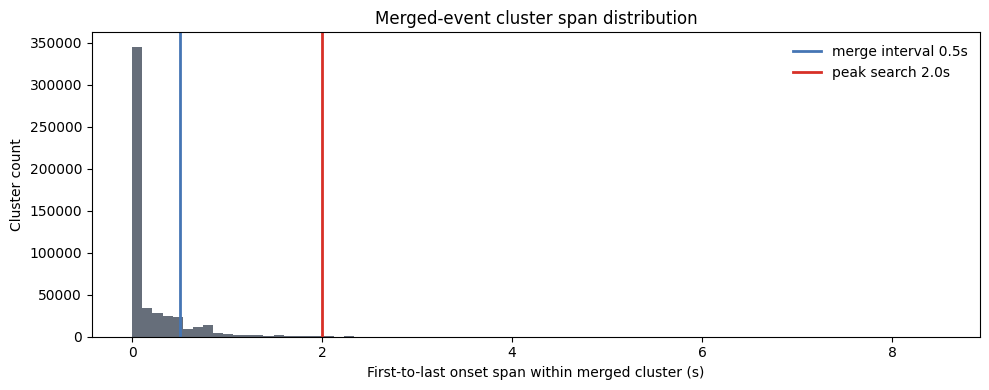

In [7]:
def summarize_event_clusters(session_dir, planes, max_frames=None, event_threshold=0.0, merge_within_s=0.5):
    rows = []
    for plane in planes:
        dff, events, timestamps = load_cached_plane(session_dir, plane, max_frames=max_frames)
        if events is None:
            continue
        frame_rate = 1 / np.nanmedian(np.diff(timestamps))
        for roi_index in range(events.shape[1]):
            onsets = _event_onsets(events[:, roi_index], event_threshold)
            clusters = _merged_event_clusters(onsets, frame_rate, merge_within_s)
            for first, last, raw_count in clusters:
                midpoint = int(round((first + last) / 2))
                rows.append({
                    "plane": plane,
                    "roi_index": roi_index,
                    "first_onset_frame": first,
                    "last_onset_frame": last,
                    "midpoint_frame": midpoint,
                    "first_onset_s": timestamps[first],
                    "last_onset_s": timestamps[last],
                    "midpoint_s": timestamps[midpoint],
                    "cluster_span_s": (last - first) / frame_rate,
                    "evaluation_start_s": timestamps[max(0, midpoint - int(round(LOCAL_BASELINE_PRE_S * frame_rate)))],
                    "evaluation_end_s": timestamps[min(len(timestamps) - 1, midpoint + int(round(PEAK_SEARCH_POST_S * frame_rate)))],
                    "raw_onsets_in_cluster": raw_count,
                })
    return pd.DataFrame(rows)

cluster_summary = summarize_event_clusters(
    SESSION_DIR,
    planes_to_run,
    max_frames=MAX_FRAMES,
    event_threshold=EVENT_THRESHOLD,
    merge_within_s=MERGE_WITHIN_S,
)

if cluster_summary.empty:
    print("No event clusters found.")
else:
    by_plane = cluster_summary.groupby("plane").agg(
        n_clusters=("cluster_span_s", "size"),
        median_cluster_span_s=("cluster_span_s", "median"),
        p95_cluster_span_s=("cluster_span_s", lambda x: np.nanpercentile(x, 95)),
        max_cluster_span_s=("cluster_span_s", "max"),
        max_raw_onsets_in_cluster=("raw_onsets_in_cluster", "max"),
    )
    display(by_plane)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(cluster_summary["cluster_span_s"], bins=80, color="#4b5563", alpha=0.85)
    ax.axvline(MERGE_WITHIN_S, color="#4575b4", lw=2, label=f"merge interval {MERGE_WITHIN_S}s")
    ax.axvline(PEAK_SEARCH_POST_S, color="#d73027", lw=2, label=f"peak search {PEAK_SEARCH_POST_S}s")
    ax.set_xlabel("First-to-last onset span within merged cluster (s)")
    ax.set_ylabel("Cluster count")
    ax.set_title("Merged-event cluster span distribution")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


## Event merging, midpoint calculation, and event-length examples

Raw event onsets that occur within `MERGE_WITHIN_S` of each other are merged into one event cluster. For each merged cluster:

- `first_onset` is the first raw onset in the cluster.
- `last_onset` is the last raw onset in the cluster.
- `cluster_span_s = last_onset_s - first_onset_s`.
- `midpoint_frame = round((first_onset_frame + last_onset_frame) / 2)`.
- The evaluation window is `LOCAL_BASELINE_PRE_S` before the midpoint to `PEAK_SEARCH_POST_S` after the midpoint.

The distribution below separates short/normal events, warning windows (`>=3 s`), severe windows (`>=5 s`), and extreme outliers (`>=8 s`). If event-triggered averages show that transients are no longer rising at the right edge of the window, future iterations can shorten the response window and reduce accidental merging of nearby events.

span_category
single/near-single    456301
normal <3s             54788
warning 3-5s             206
severe 5-8s               21
extreme >=8s               2
Name: n_event_clusters, dtype: int64

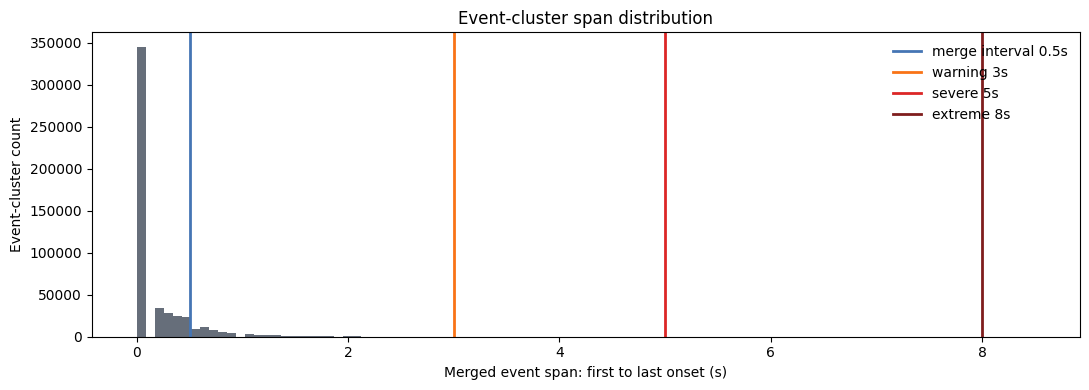

In [8]:
if cluster_summary.empty:
    print("No event clusters found.")
else:
    cluster_summary_meta = with_plane_metadata(cluster_summary)
    bins = [0, MERGE_WITHIN_S, LONG_CLUSTER_WARNING_S, LONG_CLUSTER_SEVERE_S, LONG_CLUSTER_EXTREME_S, np.inf]
    labels = ["single/near-single", f"normal <{LONG_CLUSTER_WARNING_S:g}s", f"warning {LONG_CLUSTER_WARNING_S:g}-{LONG_CLUSTER_SEVERE_S:g}s", f"severe {LONG_CLUSTER_SEVERE_S:g}-{LONG_CLUSTER_EXTREME_S:g}s", f"extreme >={LONG_CLUSTER_EXTREME_S:g}s"]
    cluster_summary_meta["span_category"] = pd.cut(cluster_summary_meta["cluster_span_s"], bins=bins, labels=labels, include_lowest=True, right=False)
    display(cluster_summary_meta["span_category"].value_counts(dropna=False).sort_index().rename("n_event_clusters"))

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.hist(cluster_summary_meta["cluster_span_s"], bins=100, color="#4b5563", alpha=0.85)
    for x, label, color in [
        (MERGE_WITHIN_S, "merge interval", "#4575b4"),
        (LONG_CLUSTER_WARNING_S, "warning", "#f97316"),
        (LONG_CLUSTER_SEVERE_S, "severe", "#dc2626"),
        (LONG_CLUSTER_EXTREME_S, "extreme", "#7f1d1d"),
    ]:
        ax.axvline(x, color=color, lw=2, label=f"{label} {x:g}s")
    ax.set_xlabel("Merged event span: first to last onset (s)")
    ax.set_ylabel("Event-cluster count")
    ax.set_title("Event-cluster span distribution")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    normal_examples = cluster_summary_meta.loc[cluster_summary_meta["cluster_span_s"].between(0, MERGE_WITHIN_S, inclusive="both")].sample(min(3, (cluster_summary_meta["cluster_span_s"] <= MERGE_WITHIN_S).sum()), random_state=7) if (cluster_summary_meta["cluster_span_s"] <= MERGE_WITHIN_S).any() else pd.DataFrame()
    warning_examples = cluster_summary_meta.loc[cluster_summary_meta["cluster_span_s"].between(LONG_CLUSTER_WARNING_S, LONG_CLUSTER_SEVERE_S, inclusive="left")].sort_values("cluster_span_s", ascending=False).head(3)
    long_examples = cluster_summary_meta.sort_values("cluster_span_s", ascending=False).head(3)

    plot_trace_stack(normal_examples, title="Normal/short merged-event windows", center_col="midpoint_s", window_pre_s=0.5, window_post_s=2.0)
    plot_trace_stack(warning_examples, title="Warning merged-event windows", center_col="midpoint_s", window_pre_s=0.5, window_post_s=2.0)
    plot_trace_stack(long_examples, title="Longest outlier merged-event windows", center_col="midpoint_s", window_pre_s=0.5, window_post_s=2.0)
    plt.show()


## Metric distributions

These plots show the background/event metrics used for the cluster analysis presentation:

- `background_noise_sd`: baseline noise from non-event dF/F samples.
- `background_event_median_amp_noise_units`: typical merged-event amplitude in background SD units.
- `background_event_fraction_lt_2sd`, `background_event_fraction_2_4sd`, `background_event_fraction_gt_4sd`: where detected event clusters fall relative to background.
- `event_exp_gauss_fit_score`: whether extracted event amplitudes look exponential and residual error looks Gaussian. Higher is better.

The event-fit score is complementary to amplitude-over-background metrics: it asks whether the detected-event amplitudes and residuals have distributional behavior consistent with the assumptions behind deconvolution/event extraction rather than only asking whether events are large. Allen-related work describes using L0 event extraction before response metrics, and Allen docs describe these released event traces as part of the ophys product: [Allen-related L0 event extraction methods](https://pmc.ncbi.nlm.nih.gov/articles/PMC8285106/), [AllenSDK visual behavior optical physiology docs](https://allensdk.readthedocs.io/en/latest/visual_behavior_optical_physiology.html).

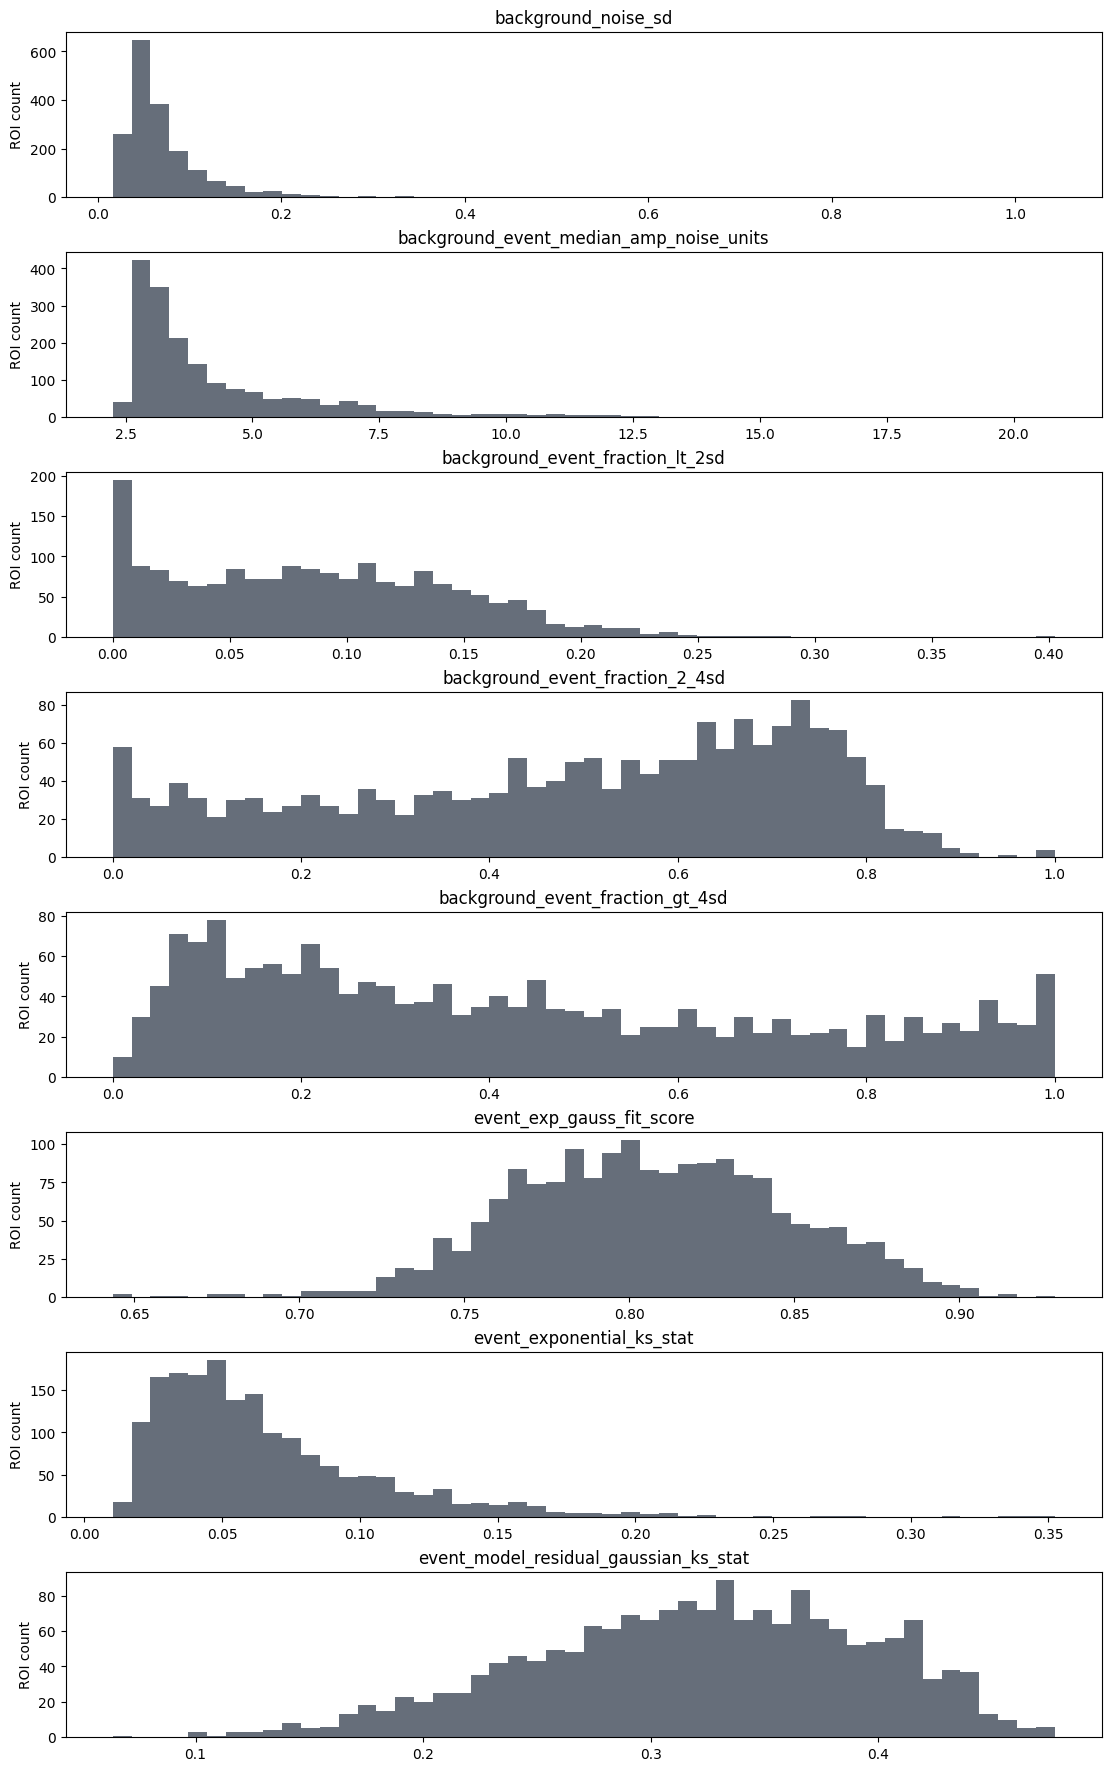

In [9]:
plot_cols = [
    "background_noise_sd",
    "background_event_median_amp_noise_units",
    "background_event_fraction_lt_2sd",
    "background_event_fraction_2_4sd",
    "background_event_fraction_gt_4sd",
    "event_exp_gauss_fit_score",
    "event_exponential_ks_stat",
    "event_model_residual_gaussian_ks_stat",
]
plot_cols = [c for c in plot_cols if c in roi_metrics.columns]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(11, 2.2 * len(plot_cols)), constrained_layout=True)
if len(plot_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, plot_cols):
    vals = pd.to_numeric(roi_metrics[col], errors="coerce").dropna()
    ax.hist(vals, bins=50, color="#4b5563", alpha=0.85)
    ax.set_title(col)
    ax.set_ylabel("ROI count")
plt.show()

## Event amplitude bands

This summarizes the collaborator's proposed bins directly. For a clean ROI, a useful event detector should produce many merged events above background, not mostly events inside the background distribution.

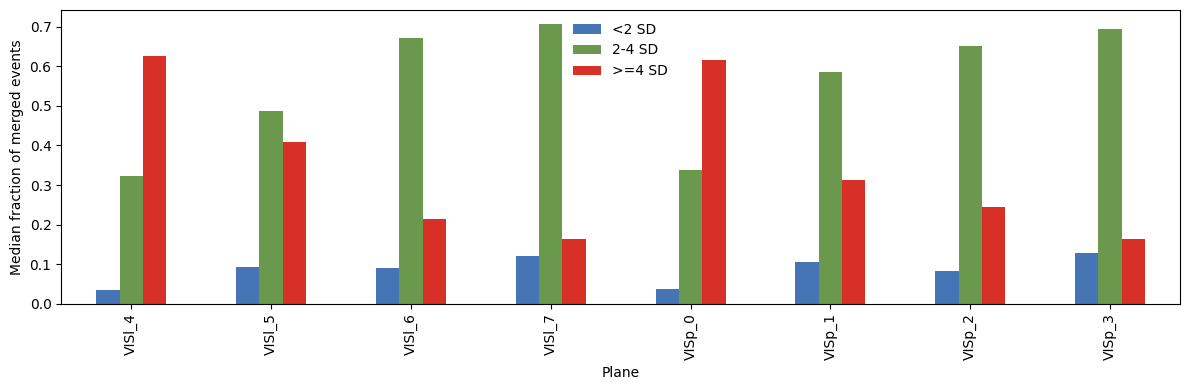

,background_event_fraction_lt_2sd,background_event_fraction_2_4sd,background_event_fraction_gt_4sd
plane,,,
VISl_4,0.035191,0.323810,0.626667
VISl_5,0.093074,0.487552,0.407708
VISl_6,0.090062,0.672414,0.214286
VISl_7,0.119524,0.707108,0.163590
VISp_0,0.037736,0.338422,0.615385
VISp_1,0.104212,0.586310,0.313362
VISp_2,0.081899,0.651484,0.245689
VISp_3,0.127424,0.693416,0.163265


In [10]:
band_cols = [
    "background_event_fraction_lt_2sd",
    "background_event_fraction_2_4sd",
    "background_event_fraction_gt_4sd",
]
summary = roi_metrics.groupby("plane")[band_cols].median(numeric_only=True)
ax = summary.plot(kind="bar", figsize=(12, 4), color=["#4575b4", "#6a994e", "#d73027"])
ax.set_ylabel("Median fraction of merged events")
ax.set_xlabel("Plane")
ax.legend(["<2 SD", "2-4 SD", ">=4 SD"], frameon=False)
plt.tight_layout()
plt.show()
summary

## ROI event-composition clustering

This section asks whether each ROI is primarily composed of one event-amplitude category: events below `2 SD`, events between `2-4 SD`, or events above `4 SD` relative to the ROI background. It reports both rule-based labels and an unsupervised k-means clustering on the three event-fraction columns.

The rule label is intentionally conservative. A ROI is called mostly one type only if the largest fraction is at least `55%` and exceeds the second-largest fraction by at least `15%`; otherwise it is labeled `mixed_or_ambiguous`. The cluster centroids are useful for deciding whether the data actually separate, or whether the event composition is mostly continuous.


In [11]:
COMPOSITION_DOMINANCE_THRESHOLD = 0.55
COMPOSITION_AMBIGUITY_MARGIN = 0.15
roi_metrics_labeled = event_composition_labels(
    roi_metrics,
    dominance_threshold=COMPOSITION_DOMINANCE_THRESHOLD,
    ambiguity_margin=COMPOSITION_AMBIGUITY_MARGIN,
)
roi_metrics_labeled, event_composition_centroids = event_composition_kmeans(
    roi_metrics_labeled,
    n_clusters=3,
)

# Merge long-window flags when the cluster diagnostics table has been computed.
if "cluster_summary" in globals() and not cluster_summary.empty:
    long_window_roi_flags = long_event_window_flags(
        cluster_summary,
        warning_span_s=LONG_CLUSTER_WARNING_S,
        severe_span_s=LONG_CLUSTER_SEVERE_S,
        extreme_span_s=LONG_CLUSTER_EXTREME_S,
    )
    roi_metrics_labeled = roi_metrics_labeled.merge(
        long_window_roi_flags,
        on=["plane", "roi_index"],
        how="left",
    )
else:
    long_window_roi_flags = pd.DataFrame()

flag_cols = [c for c in roi_metrics_labeled.columns if c.startswith("n_") and "long_event" in c]
for col in flag_cols:
    roi_metrics_labeled[col] = roi_metrics_labeled[col].fillna(0).astype(int)
for col in [c for c in roi_metrics_labeled.columns if c.startswith("has_") and "long_event" in c]:
    roi_metrics_labeled[col] = roi_metrics_labeled[col].where(roi_metrics_labeled[col].notna(), False).astype(bool)

labeled_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_background_event_roi_metrics_labeled.csv"
centroids_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_event_composition_cluster_centroids.csv"
roi_metrics_labeled.to_csv(labeled_csv, index=False)
event_composition_centroids.to_csv(centroids_csv, index=False)
print(f"Saved labeled ROI metrics to {labeled_csv}")
print(f"Saved event-composition centroids to {centroids_csv}")

display(roi_metrics_labeled["event_composition_label"].value_counts(dropna=False).rename("n_rois"))
display(event_composition_centroids)

cluster_counts = pd.crosstab(
    roi_metrics_labeled["event_composition_cluster"],
    roi_metrics_labeled["event_composition_label"],
    dropna=False,
)
display(cluster_counts)


Saved labeled ROI metrics to /storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/background_event_qc/multiplane-ophys_839909_2026-02-20_12-53-27_background_event_roi_metrics_labeled.csv
Saved event-composition centroids to /storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/background_event_qc/multiplane-ophys_839909_2026-02-20_12-53-27_event_composition_cluster_centroids.csv


event_composition_label
mostly_2_4sd            862
mostly_gt_4sd           590
mixed_or_ambiguous      357
no_events_or_missing      1
Name: n_rois, dtype: int64

,event_composition_cluster,n_rois,centroid_fraction_lt_2sd,centroid_fraction_2_4sd,centroid_fraction_gt_4sd,mean_distance_to_centroid
0,0,805,0.128975,0.707331,0.163693,0.111251
1,1,553,0.076366,0.447234,0.476400,0.117638
2,2,451,0.020079,0.135195,0.844726,0.121640


event_composition_label,mixed_or_ambiguous,mostly_2_4sd,mostly_gt_4sd,no_events_or_missing
event_composition_cluster,,,,
0.0,6,799,0,0
1.0,351,63,139,0
2.0,0,0,451,0
NaN,0,0,0,1


## Event-composition visualization

The ternary-like scatter below projects the three event fractions into two dimensions. ROIs near the left/lower side are mostly `<2 SD` or `2-4 SD`; ROIs toward the upper right are enriched for `>=4 SD` events. If clusters overlap heavily rather than forming separated clouds, the metric is probably continuous and thresholds should be treated as tunable QC cutoffs rather than natural cell classes.


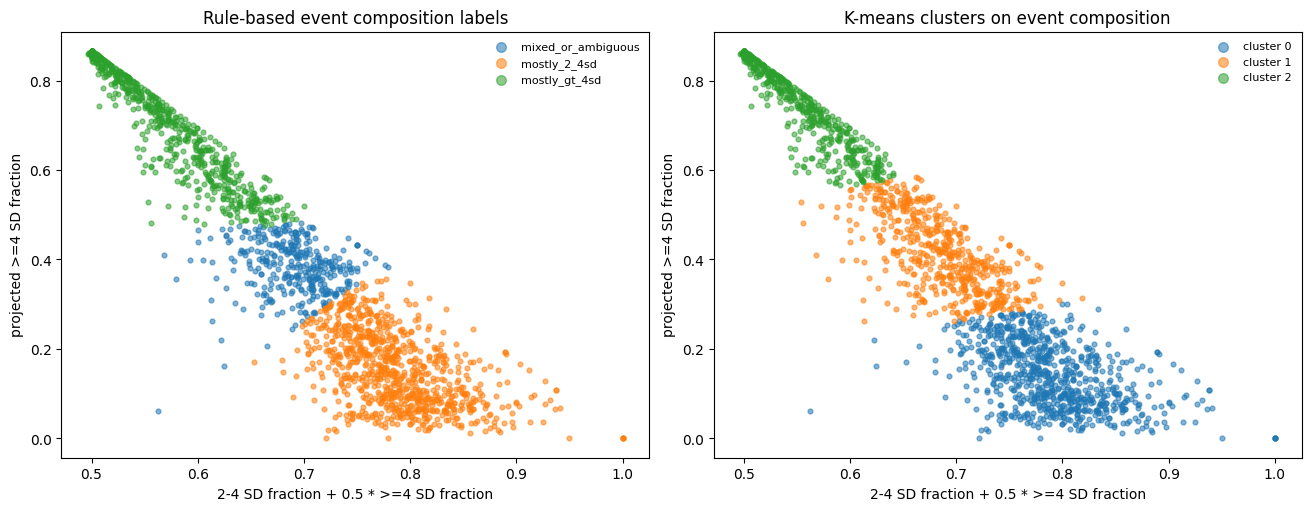

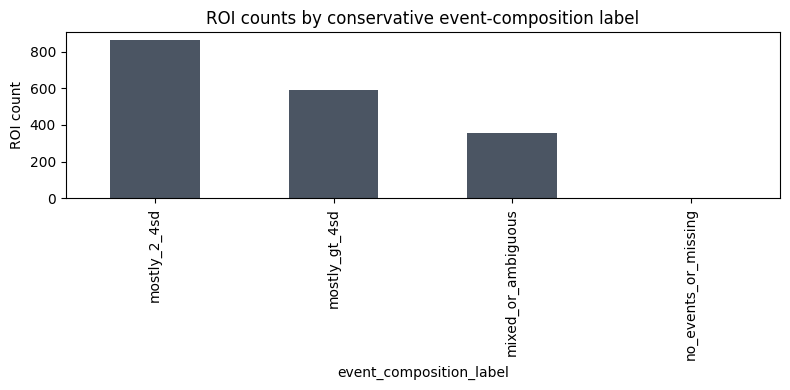

In [12]:
composition_cols = [
    "background_event_fraction_lt_2sd",
    "background_event_fraction_2_4sd",
    "background_event_fraction_gt_4sd",
]
plot_df = roi_metrics_labeled.dropna(subset=composition_cols).copy()
# Simple barycentric projection for three fractions.
plot_df["composition_x"] = plot_df["background_event_fraction_2_4sd"] + 0.5 * plot_df["background_event_fraction_gt_4sd"]
plot_df["composition_y"] = (np.sqrt(3) / 2) * plot_df["background_event_fraction_gt_4sd"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for label, group in plot_df.groupby("event_composition_label"):
    axes[0].scatter(group["composition_x"], group["composition_y"], s=12, alpha=0.55, label=label)
axes[0].set_title("Rule-based event composition labels")
axes[0].set_xlabel("2-4 SD fraction + 0.5 * >=4 SD fraction")
axes[0].set_ylabel("projected >=4 SD fraction")
axes[0].legend(markerscale=2, frameon=False, fontsize=8)

for cluster, group in plot_df.groupby("event_composition_cluster"):
    axes[1].scatter(group["composition_x"], group["composition_y"], s=12, alpha=0.55, label=f"cluster {int(cluster)}")
axes[1].set_title("K-means clusters on event composition")
axes[1].set_xlabel("2-4 SD fraction + 0.5 * >=4 SD fraction")
axes[1].set_ylabel("projected >=4 SD fraction")
axes[1].legend(markerscale=2, frameon=False, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
label_order = roi_metrics_labeled["event_composition_label"].value_counts().index
roi_metrics_labeled["event_composition_label"].value_counts().loc[label_order].plot(kind="bar", ax=ax, color="#4b5563")
ax.set_ylabel("ROI count")
ax.set_title("ROI counts by conservative event-composition label")
plt.tight_layout()
plt.show()


## 3D event composition excluding long clusters

This version treats merged event clusters with span `>=3 s` as a separate `long_gt_3s` category. Those long clusters are **not** included when calculating the three event-type percentages used for ROI clustering. The 3D coordinates are therefore:

- x: fraction of non-long events `<2 SD`
- y: fraction of non-long events `2-4 SD`
- z: fraction of non-long events `>=4 SD`

Point color shows k-means membership based only on those three non-long fractions. A black marker edge means the ROI had at least one `>=3 s` event cluster, so it should be inspected separately even though those long events were excluded from the composition used for clustering.


In [13]:
LONG_EVENT_CATEGORY_SPAN_S = 3.0

cluster_amp_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_event_clusters_with_amplitude_classes.csv"
nonlong_composition_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_nonlong_event_composition_by_roi.csv"
nonlong_annotated_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_roi_metrics_with_nonlong_event_composition.csv"
nonlong_centroids_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_nonlong_event_composition_centroids.csv"
composition_3d_png = OUTPUT_DIR / f"{SESSION_DIR.name}_nonlong_event_composition_3d.png"

if cluster_amp_csv.exists() and nonlong_composition_csv.exists() and nonlong_centroids_csv.exists():
    cluster_amp_table = pd.read_csv(cluster_amp_csv)
    nonlong_composition = pd.read_csv(nonlong_composition_csv)
    nonlong_centroids = pd.read_csv(nonlong_centroids_csv)
else:
    cluster_amp_tables = []
    for plane in planes_to_run:
        dff, events, timestamps = load_cached_plane(SESSION_DIR, plane, max_frames=MAX_FRAMES)
        plane_metrics = roi_metrics_labeled.loc[roi_metrics_labeled["plane"].astype(str) == str(plane)] if "roi_metrics_labeled" in globals() else roi_metrics.loc[roi_metrics["plane"].astype(str) == str(plane)]
        table = event_cluster_amplitude_table(
            dff,
            events,
            timestamps,
            roi_metrics=plane_metrics,
            plane=plane,
            event_threshold=EVENT_THRESHOLD,
            merge_within_s=MERGE_WITHIN_S,
            local_baseline_pre_s=LOCAL_BASELINE_PRE_S,
            peak_search_post_s=PEAK_SEARCH_POST_S,
            long_span_s=LONG_EVENT_CATEGORY_SPAN_S,
        )
        table.insert(0, "session", SESSION_DIR.name)
        cluster_amp_tables.append(table)
    cluster_amp_table = pd.concat(cluster_amp_tables, ignore_index=True)
    nonlong_composition = roi_event_composition_from_cluster_table(
        cluster_amp_table,
        group_cols=("plane", "roi_index"),
    )
    nonlong_composition.insert(0, "session", SESSION_DIR.name)

    kmeans_input = nonlong_composition.rename(columns={
        "nonlong_event_fraction_lt_2sd": "background_event_fraction_lt_2sd",
        "nonlong_event_fraction_2_4sd": "background_event_fraction_2_4sd",
        "nonlong_event_fraction_gt_4sd": "background_event_fraction_gt_4sd",
    })
    kmeans_labeled, nonlong_centroids = event_composition_kmeans(kmeans_input, n_clusters=3)
    nonlong_composition["nonlong_event_composition_cluster"] = kmeans_labeled["event_composition_cluster"]
    nonlong_centroids = nonlong_centroids.rename(columns={
        "event_composition_cluster": "nonlong_event_composition_cluster",
        "centroid_fraction_lt_2sd": "centroid_nonlong_fraction_lt_2sd",
        "centroid_fraction_2_4sd": "centroid_nonlong_fraction_2_4sd",
        "centroid_fraction_gt_4sd": "centroid_nonlong_fraction_gt_4sd",
    })
    cluster_amp_table.to_csv(cluster_amp_csv, index=False)
    nonlong_composition.to_csv(nonlong_composition_csv, index=False)
    nonlong_centroids.to_csv(nonlong_centroids_csv, index=False)

roi_metrics_nonlong = roi_metrics_labeled.merge(
    nonlong_composition,
    on=["session", "plane", "roi_index"],
    how="left",
    suffixes=("", "_nonlong"),
) if "roi_metrics_labeled" in globals() else roi_metrics.merge(
    nonlong_composition,
    on=["session", "plane", "roi_index"],
    how="left",
    suffixes=("", "_nonlong"),
)
roi_metrics_nonlong.to_csv(nonlong_annotated_csv, index=False)

print("Event cluster type counts with >=3 s clusters separated:")
display(cluster_amp_table["event_type"].value_counts().rename("n_clusters"))
print("Non-long composition centroids:")
display(nonlong_centroids)
print(f"ROIs with at least one >=3 s cluster: {int(nonlong_composition['has_long_gt_3s_event_cluster'].sum())} / {len(nonlong_composition)}")


Event cluster type counts with >=3 s clusters separated:


event_type
2_4sd         232988
gt_4sd        231869
lt_2sd         46232
long_gt_3s       229
Name: n_clusters, dtype: int64

Non-long composition centroids:


,nonlong_event_composition_cluster,n_rois,centroid_nonlong_fraction_lt_2sd,centroid_nonlong_fraction_2_4sd,centroid_nonlong_fraction_gt_4sd,mean_distance_to_centroid
0,0,805,0.128952,0.707351,0.163697,0.111230
1,1,553,0.076305,0.447247,0.476448,0.117608
2,2,451,0.020061,0.135171,0.844768,0.121584


ROIs with at least one >=3 s cluster: 151 / 1809


## Event-type proportions per ROI by region and layer

For each ROI, we count merged event clusters in the `<2 SD`, `2-4 SD`, `>4 SD`, and `>=3 s long` categories. The stacked bars show the average per-ROI proportions within each region/depth group. This is the summary that motivates the later 3D composition space.

,structure,depth_um,plane,nonlong_event_fraction_lt_2sd,nonlong_event_fraction_2_4sd,nonlong_event_fraction_gt_4sd,long_gt_3s_fraction_all_clusters
0,VISl,62.0,VISl_6,0.089409,0.615959,0.294632,0.000354
1,VISl,200.0,VISl_4,0.051841,0.333824,0.614334,0.000156
2,VISl,300.0,VISl_5,0.095629,0.462004,0.442367,0.000531
3,VISl,400.0,VISl_7,0.119812,0.638809,0.241379,0.000127
4,VISp,64.0,VISp_2,0.082707,0.602507,0.314786,0.000123
5,VISp,196.0,VISp_0,0.049524,0.345474,0.605002,0.000108
6,VISp,314.0,VISp_1,0.105357,0.536312,0.358331,0.000592
7,VISp,400.0,VISp_3,0.123905,0.639995,0.236100,0.000283


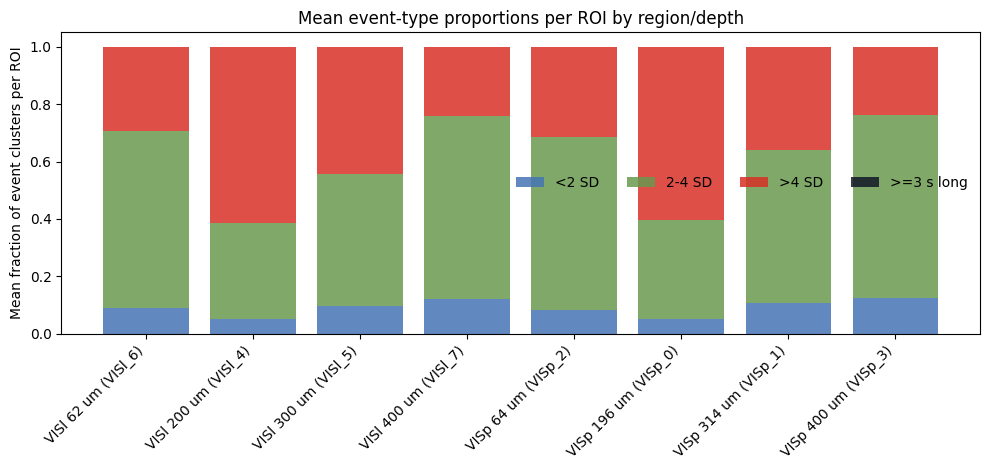

In [14]:
composition_for_summary = with_plane_metadata(nonlong_composition if "nonlong_composition" in globals() else roi_metrics_labeled)
if composition_for_summary is None or composition_for_summary.empty:
    print("No composition table available yet. Run the non-long event-composition cell first.")
else:
    prop_cols = [
        "nonlong_event_fraction_lt_2sd",
        "nonlong_event_fraction_2_4sd",
        "nonlong_event_fraction_gt_4sd",
        "long_gt_3s_fraction_all_clusters",
    ]
    prop_labels = ["<2 SD", "2-4 SD", ">4 SD", ">=3 s long"]
    group_cols = ["structure", "depth_um", "plane"]
    prop_summary = composition_for_summary.groupby(group_cols, dropna=False)[prop_cols].mean().reset_index()
    display(prop_summary)

    x = np.arange(len(prop_summary))
    fig, ax = plt.subplots(figsize=(max(10, 0.8 * len(prop_summary)), 4.8))
    bottom = np.zeros(len(prop_summary))
    colors = ["#4575b4", "#6a994e", "#d73027", "#111827"]
    for col, label, color in zip(prop_cols, prop_labels, colors):
        vals = prop_summary[col].fillna(0).to_numpy()
        ax.bar(x, vals, bottom=bottom, label=label, color=color, alpha=0.85)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels([plane_depth_label(row) for _, row in prop_summary.iterrows()], rotation=45, ha="right")
    ax.set_ylabel("Mean fraction of event clusters per ROI")
    ax.set_title("Mean event-type proportions per ROI by region/depth")
    ax.legend(frameon=False, ncol=4)
    plt.tight_layout()
    plt.show()


## Absolute event-type counts per ROI by region and layer

Proportions are useful for defining ROI composition, but absolute counts matter too. A cell with only one event can have a misleading proportion. These bars show the average number of event clusters of each type per ROI, grouped by region/depth.

,structure,depth_um,plane,n_lt_2sd_event_clusters,n_2_4sd_event_clusters,n_gt_4sd_event_clusters,n_long_gt_3s_event_clusters
0,VISl,62.0,VISl_6,18.840000,94.613333,68.800000,0.160000
1,VISl,200.0,VISl_4,13.350427,73.472934,142.712251,0.062678
2,VISl,300.0,VISl_5,41.353191,187.523404,207.480851,0.268085
3,VISl,400.0,VISl_7,29.364583,143.142361,74.565972,0.055556
4,VISp,64.0,VISp_2,14.333333,85.833333,55.190476,0.059524
5,VISp,196.0,VISp_0,12.837681,79.730435,144.591304,0.046377
6,VISp,314.0,VISp_1,43.756522,213.913043,164.421739,0.304348
7,VISp,400.0,VISp_3,31.149254,153.696517,69.885572,0.124378


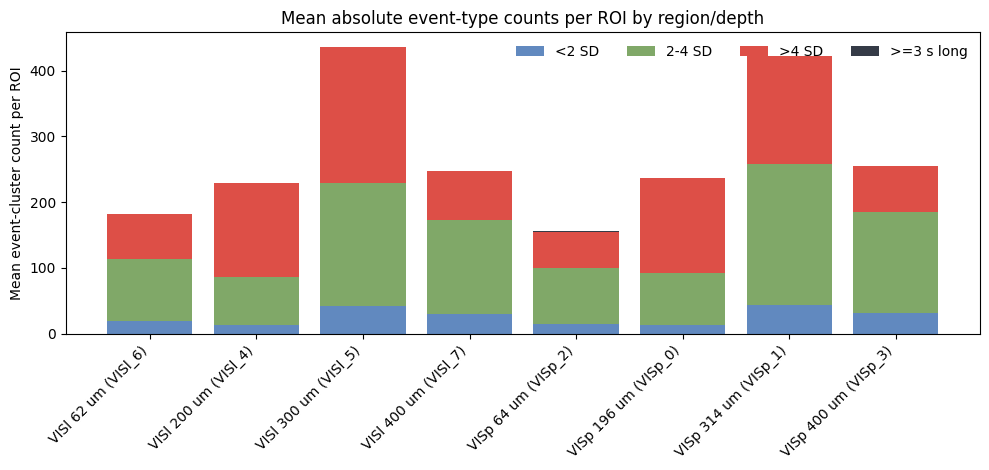

In [15]:
if "nonlong_composition" not in globals() or nonlong_composition.empty:
    print("No non-long composition table available yet.")
else:
    count_df = with_plane_metadata(nonlong_composition)
    count_cols = [
        "n_lt_2sd_event_clusters",
        "n_2_4sd_event_clusters",
        "n_gt_4sd_event_clusters",
        "n_long_gt_3s_event_clusters",
    ]
    count_labels = ["<2 SD", "2-4 SD", ">4 SD", ">=3 s long"]
    count_summary = count_df.groupby(["structure", "depth_um", "plane"], dropna=False)[count_cols].mean().reset_index()
    display(count_summary)

    x = np.arange(len(count_summary))
    fig, ax = plt.subplots(figsize=(max(10, 0.8 * len(count_summary)), 4.8))
    bottom = np.zeros(len(count_summary))
    colors = ["#4575b4", "#6a994e", "#d73027", "#111827"]
    for col, label, color in zip(count_cols, count_labels, colors):
        vals = count_summary[col].fillna(0).to_numpy()
        ax.bar(x, vals, bottom=bottom, label=label, color=color, alpha=0.85)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels([plane_depth_label(row) for _, row in count_summary.iterrows()], rotation=45, ha="right")
    ax.set_ylabel("Mean event-cluster count per ROI")
    ax.set_title("Mean absolute event-type counts per ROI by region/depth")
    ax.legend(frameon=False, ncol=4)
    plt.tight_layout()
    plt.show()


## ROIs with no events or very few events

ROIs with no detected events, or very few event clusters, are useful sanity checks. If no true zero-event ROIs exist in this session, the cell shows the lowest-count ROIs instead. These traces help separate quiet but plausible ROIs from ROIs that look like poor extraction or mostly flat noise.

In [16]:
if "nonlong_composition" in globals() and not nonlong_composition.empty:
    low_count = with_plane_metadata(nonlong_composition).copy()
    low_count["total_event_clusters"] = low_count[["n_lt_2sd_event_clusters", "n_2_4sd_event_clusters", "n_gt_4sd_event_clusters", "n_long_gt_3s_event_clusters"]].sum(axis=1)
else:
    low_count = with_plane_metadata(roi_metrics_labeled if "roi_metrics_labeled" in globals() else roi_metrics).copy()
    low_count["total_event_clusters"] = low_count.get("background_event_cluster_count", np.nan)

zero_event = low_count.loc[low_count["total_event_clusters"].fillna(0) == 0]
print(f"ROIs with zero event clusters: {len(zero_event)}")
examples = zero_event.head(5) if len(zero_event) else low_count.sort_values("total_event_clusters", na_position="last").head(5)
display(examples[["plane", "roi_index", "structure", "depth_um", "total_event_clusters"]])
plot_trace_stack(examples, title="No-event ROIs, or lowest-count ROIs if none are zero", max_rois=5)
plt.show()


ROIs with zero event clusters: 0


,plane,roi_index,structure,depth_um,total_event_clusters
630,VISl_6,45,VISl,62.0,1
1542,VISp_2,18,VISp,64.0,1
1575,VISp_2,51,VISp,64.0,3
267,VISl_4,267,VISl,200.0,3
350,VISl_4,350,VISl,200.0,4


## From summaries to a 3D event-composition space

After separating long `>=3 s` windows, each ROI is represented by three proportions: fraction of non-long event clusters that are `<2 SD`, `2-4 SD`, and `>4 SD`. These three numbers define a compact space for sorting ROIs. We then use k-means with `k=3` to define three empirical ROI groups.

In this session, `<2 SD` event clusters are relatively rare overall. When a ROI has a higher fraction of `<2 SD` events, that often indicates low-amplitude detected events near the background scale, which tends to align with noisier recordings. The correlation check below makes that relationship explicit.

,nonlong_event_fraction_lt_2sd,background_noise_sd,event_exp_gauss_fit_score,background_event_median_amp_noise_units
nonlong_event_fraction_lt_2sd,1.000000,0.087153,0.031402,-0.849884
background_noise_sd,0.087153,1.000000,0.076544,-0.109822
event_exp_gauss_fit_score,0.031402,0.076544,1.000000,-0.077362
background_event_median_amp_noise_units,-0.849884,-0.109822,-0.077362,1.000000


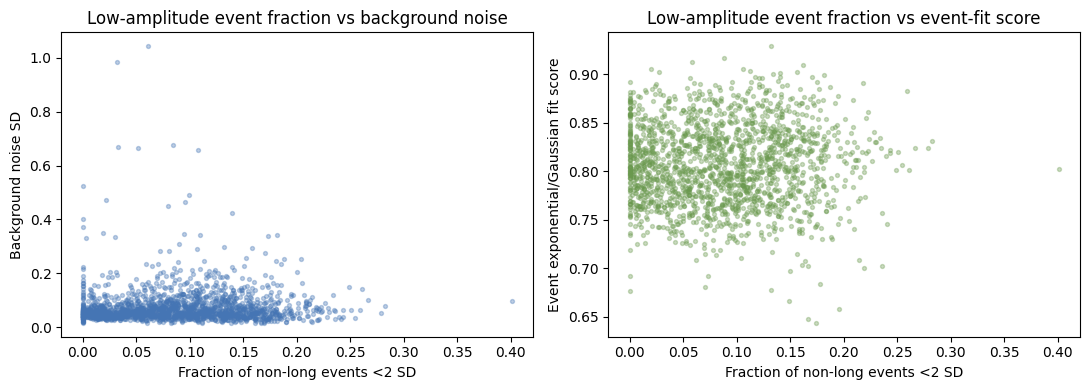

In [17]:
if "roi_metrics_nonlong" in globals():
    corr_cols = ["nonlong_event_fraction_lt_2sd", "background_noise_sd", "event_exp_gauss_fit_score", "background_event_median_amp_noise_units"]
    corr_df = roi_metrics_nonlong[corr_cols].apply(pd.to_numeric, errors="coerce")
    display(corr_df.corr(method="spearman"))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(corr_df["nonlong_event_fraction_lt_2sd"], corr_df["background_noise_sd"], s=8, alpha=0.35, color="#4575b4")
    axes[0].set_xlabel("Fraction of non-long events <2 SD")
    axes[0].set_ylabel("Background noise SD")
    axes[0].set_title("Low-amplitude event fraction vs background noise")
    axes[1].scatter(corr_df["nonlong_event_fraction_lt_2sd"], corr_df["event_exp_gauss_fit_score"], s=8, alpha=0.35, color="#6a994e")
    axes[1].set_xlabel("Fraction of non-long events <2 SD")
    axes[1].set_ylabel("Event exponential/Gaussian fit score")
    axes[1].set_title("Low-amplitude event fraction vs event-fit score")
    plt.tight_layout()
    plt.show()
else:
    print("Run the non-long composition cell first.")


## 3D event-composition plot

The plot is saved to `outputs/background_event_qc`. Because the three plotted fractions sum to one after long events are excluded, the cloud should lie near a simplex surface. If the colored clusters form a smooth gradient rather than separated islands, that argues for treating the metric as continuous rather than forcing hard event-type classes.


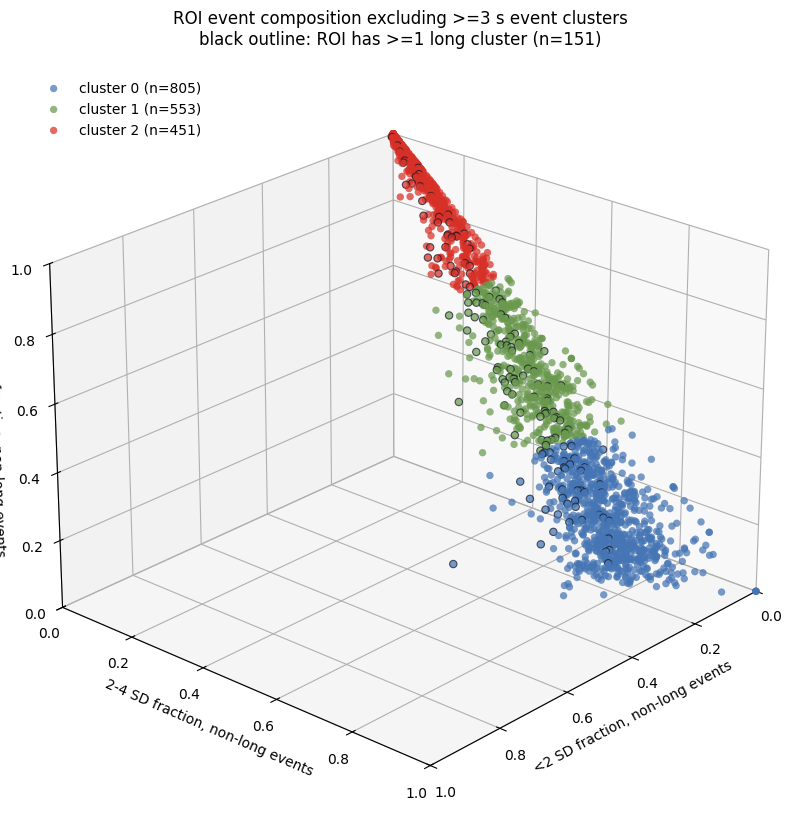

/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/background_event_qc/multiplane-ophys_839909_2026-02-20_12-53-27_nonlong_event_composition_3d.png


In [18]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plot_df = nonlong_composition.dropna(subset=[
    "nonlong_event_fraction_lt_2sd",
    "nonlong_event_fraction_2_4sd",
    "nonlong_event_fraction_gt_4sd",
    "nonlong_event_composition_cluster",
]).copy()
cluster_colors = {0: "#4575b4", 1: "#6a994e", 2: "#d73027"}

fig = plt.figure(figsize=(10.5, 8.5))
ax = fig.add_subplot(111, projection="3d")
for cluster, group in plot_df.groupby("nonlong_event_composition_cluster"):
    cluster_id = int(cluster)
    edgecolors = np.where(group["has_long_gt_3s_event_cluster"], "#111827", "none")
    linewidths = np.where(group["has_long_gt_3s_event_cluster"], 0.8, 0.0)
    ax.scatter(
        group["nonlong_event_fraction_lt_2sd"],
        group["nonlong_event_fraction_2_4sd"],
        group["nonlong_event_fraction_gt_4sd"],
        s=28,
        alpha=0.72,
        color=cluster_colors.get(cluster_id, "#64748b"),
        edgecolors=edgecolors,
        linewidths=linewidths,
        label=f"cluster {cluster_id} (n={len(group)})",
    )
ax.set_xlabel("<2 SD fraction, non-long events")
ax.set_ylabel("2-4 SD fraction, non-long events")
ax.set_zlabel(">=4 SD fraction, non-long events")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.view_init(elev=24, azim=42)
ax.set_title(
    "ROI event composition excluding >=3 s event clusters\n"
    f"black outline: ROI has >=1 long cluster (n={int(plot_df['has_long_gt_3s_event_cluster'].sum())})"
)
ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98), frameon=False)
fig.tight_layout()
fig.savefig(composition_3d_png, dpi=180)
plt.show()
print(composition_3d_png)


## Event-triggered decay and residual-noise fits by event category

For each event-size category, we align dF/F windows to the merged event midpoint, subtract a local pre-event baseline, and average the event windows. We fit a simple exponential decay after the average transient peak. Residuals around the category-average model are then compared with a Gaussian distribution.

These are diagnostic plots, not final biological model fits. They help answer whether a category contains stereotyped calcium transients or windows that are too merged/noisy to behave like one event.

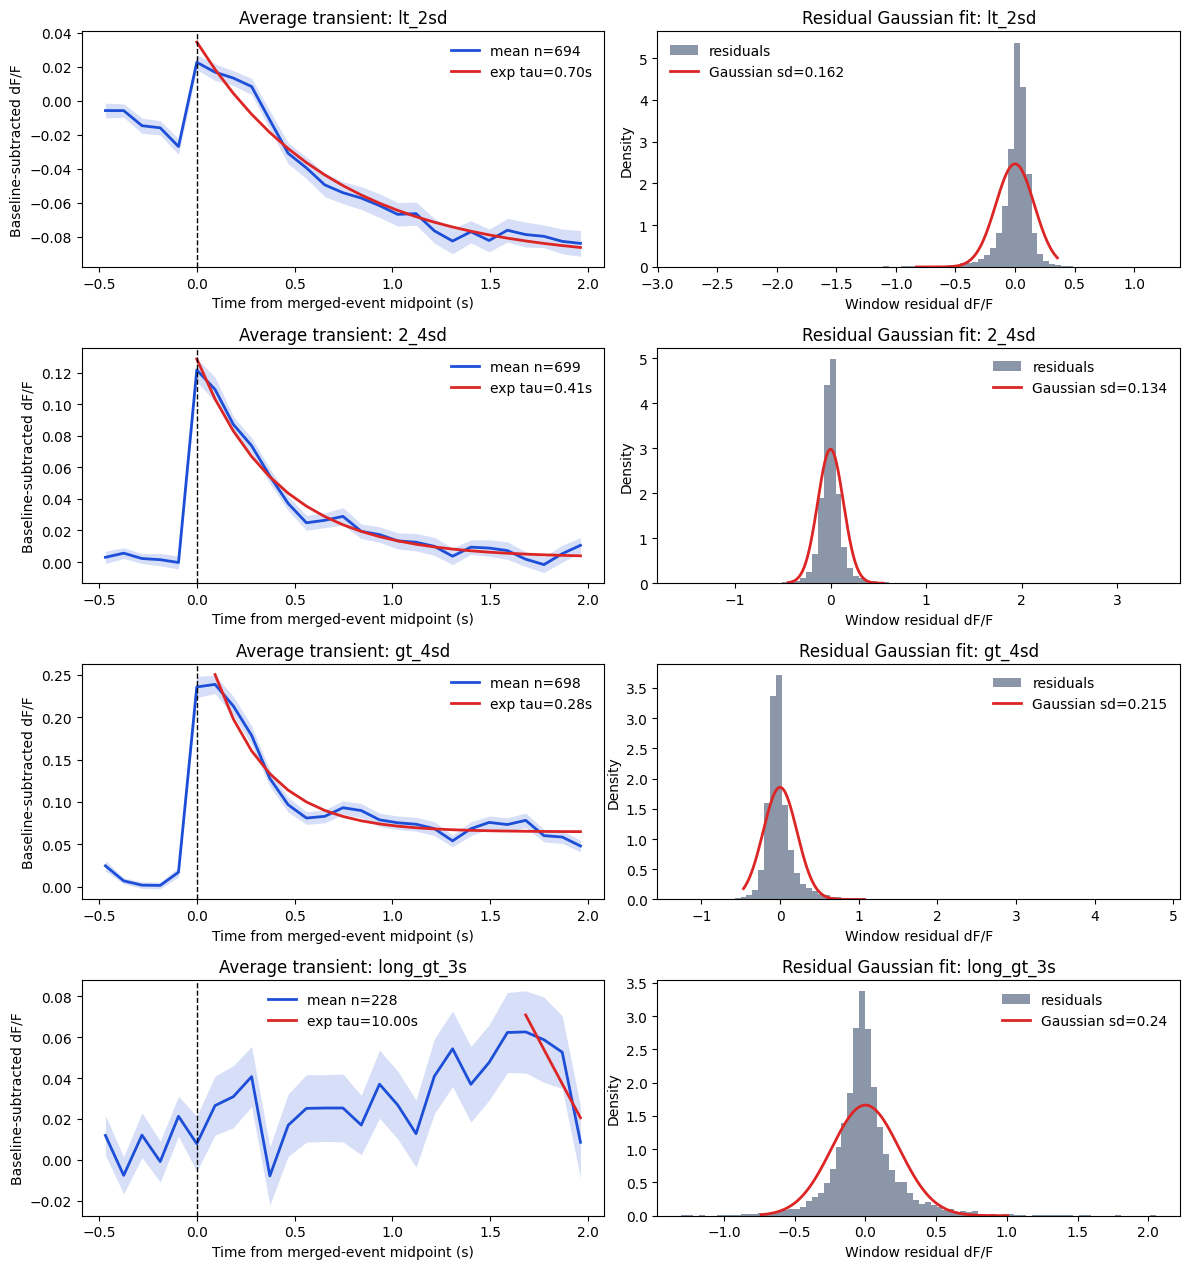

In [19]:
from scipy.optimize import curve_fit
from scipy.stats import norm

MAX_WINDOWS_PER_EVENT_TYPE = 700
EVENT_FIT_PRE_S = 0.5
EVENT_FIT_POST_S = 2.0
EVENT_FIT_RANDOM_SEED = 11


def collect_event_windows_by_type(cluster_table, event_type, max_windows=MAX_WINDOWS_PER_EVENT_TYPE):
    rows = cluster_table.loc[cluster_table["event_type"] == event_type].copy()
    if rows.empty:
        return None, None, None
    if len(rows) > max_windows:
        rows = rows.sample(max_windows, random_state=EVENT_FIT_RANDOM_SEED)
    windows = []
    rel_t_ref = None
    for plane_name, group in rows.groupby("plane"):
        dff, events, timestamps = load_cached_plane(SESSION_DIR, plane_name, max_frames=MAX_FRAMES)
        fr = _frame_rate_from_timestamps(timestamps)
        pre = int(round(EVENT_FIT_PRE_S * fr))
        post = int(round(EVENT_FIT_POST_S * fr))
        rel_t = np.arange(-pre, post + 1) / fr
        if rel_t_ref is None:
            rel_t_ref = rel_t
        for _, row in group.iterrows():
            roi = int(row.roi_index)
            mid = _frame_for_time(timestamps, row.midpoint_s)
            if mid - pre < 0 or mid + post >= len(timestamps):
                continue
            segment = np.asarray(dff[mid - pre: mid + post + 1, roi], dtype=float)
            baseline = np.nanmedian(segment[:pre]) if pre > 0 else np.nanmedian(segment)
            windows.append(segment - baseline)
    if not windows:
        return None, None, None
    min_len = min(len(w) for w in windows)
    windows = np.vstack([w[:min_len] for w in windows])
    return rel_t_ref[:min_len], windows, rows


def fit_exp_decay_to_average(rel_t, avg):
    if rel_t is None or avg is None or len(avg) < 5:
        return None
    peak_i = int(np.nanargmax(avg))
    x = rel_t[peak_i:] - rel_t[peak_i]
    y = avg[peak_i:]
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    if len(x) < 4:
        return None
    c0 = float(np.nanpercentile(y, 10))
    a0 = float(max(np.nanmax(y) - c0, 1e-6))
    tau0 = 0.5
    try:
        params, _ = curve_fit(lambda xx, a, tau, c: a * np.exp(-xx / tau) + c, x, y, p0=[a0, tau0, c0], bounds=([0, 0.05, -np.inf], [np.inf, 10.0, np.inf]), maxfev=10000)
        fit_y = params[0] * np.exp(-x / params[1]) + params[2]
        return {"peak_i": peak_i, "x": x, "y": y, "fit_y": fit_y, "amp": params[0], "tau_s": params[1], "offset": params[2]}
    except Exception:
        return None


def plot_category_fit_diagnostics(event_types=("lt_2sd", "2_4sd", "gt_4sd", "long_gt_3s")):
    fig, axes = plt.subplots(len(event_types), 2, figsize=(12, 3.2 * len(event_types)))
    axes = np.atleast_2d(axes)
    for row_i, event_type in enumerate(event_types):
        rel_t, windows, rows = collect_event_windows_by_type(cluster_amp_table, event_type)
        ax_trace, ax_resid = axes[row_i]
        if windows is None:
            ax_trace.set_title(f"{event_type}: no windows")
            ax_resid.axis("off")
            continue
        avg = np.nanmean(windows, axis=0)
        sem = np.nanstd(windows, axis=0) / np.sqrt(max(1, windows.shape[0]))
        fit = fit_exp_decay_to_average(rel_t, avg)
        ax_trace.plot(rel_t, avg, color="#1d4ed8", lw=2, label=f"mean n={windows.shape[0]}")
        ax_trace.fill_between(rel_t, avg - sem, avg + sem, color="#1d4ed8", alpha=0.18, lw=0)
        if fit is not None:
            ax_trace.plot(rel_t[fit["peak_i"]:], fit["fit_y"], color="#dc2626", lw=2, label=f"exp tau={fit['tau_s']:.2f}s")
        ax_trace.axvline(0, color="k", ls="--", lw=1)
        ax_trace.set_xlabel("Time from merged-event midpoint (s)")
        ax_trace.set_ylabel("Baseline-subtracted dF/F")
        ax_trace.set_title(f"Average transient: {event_type}")
        ax_trace.legend(frameon=False)

        model = avg
        residuals = (windows - model[None, :]).ravel()
        residuals = residuals[np.isfinite(residuals)]
        ax_resid.hist(residuals, bins=80, density=True, color="#64748b", alpha=0.75, label="residuals")
        if residuals.size > 3 and np.nanstd(residuals) > 0:
            mu, sd = float(np.nanmean(residuals)), float(np.nanstd(residuals))
            xs = np.linspace(np.nanpercentile(residuals, 0.5), np.nanpercentile(residuals, 99.5), 300)
            ax_resid.plot(xs, norm.pdf(xs, mu, sd), color="#dc2626", lw=2, label=f"Gaussian sd={sd:.3g}")
        ax_resid.set_xlabel("Window residual dF/F")
        ax_resid.set_ylabel("Density")
        ax_resid.set_title(f"Residual Gaussian fit: {event_type}")
        ax_resid.legend(frameon=False)
    plt.tight_layout()
    plt.show()


if "cluster_amp_table" in globals() and not cluster_amp_table.empty:
    plot_category_fit_diagnostics()
else:
    print("Run the cluster-amplitude table cell first.")


## Example ROI traces from cluster extremes and category boundaries

This section samples five ROIs from each informative part of event-composition space: the most `>4 SD` dominated ROIs, the most `2-4 SD` dominated ROIs, the most `<2 SD` dominated ROIs, and ROIs near pairwise category boundaries where the top two proportions are nearly tied. These are useful for visual validation of whether the k-means groups match intuitive calcium-transient quality.

In [20]:
CLUSTER_TRACE_RANDOM_SEED = 19
N_CLUSTER_TRACE_EXAMPLES = 5
TRACE_REVIEW_START_S = None
TRACE_REVIEW_END_S = None


def composition_example_groups(df, n=5):
    frac_cols = {
        "most_gt_4sd": "nonlong_event_fraction_gt_4sd",
        "most_2_4sd": "nonlong_event_fraction_2_4sd",
        "most_lt_2sd": "nonlong_event_fraction_lt_2sd",
    }
    out = {}
    valid = df.dropna(subset=list(frac_cols.values())).copy()
    for name, col in frac_cols.items():
        out[name] = valid.sort_values(col, ascending=False).head(n)
    pairs = [
        ("boundary_lt2_vs_2_4", "nonlong_event_fraction_lt_2sd", "nonlong_event_fraction_2_4sd"),
        ("boundary_2_4_vs_gt4", "nonlong_event_fraction_2_4sd", "nonlong_event_fraction_gt_4sd"),
    ]
    for name, a, b in pairs:
        tmp = valid.copy()
        tmp["boundary_distance"] = (tmp[a] - tmp[b]).abs()
        tmp["boundary_strength"] = tmp[[a, b]].max(axis=1)
        out[name] = tmp.sort_values(["boundary_distance", "boundary_strength"], ascending=[True, False]).head(n)
    return out


if "roi_metrics_nonlong" not in globals():
    print("Run the non-long composition cell first.")
else:
    examples_by_group = composition_example_groups(with_plane_metadata(roi_metrics_nonlong), n=N_CLUSTER_TRACE_EXAMPLES)
    for group_name, rows in examples_by_group.items():
        display_cols = ["plane", "roi_index", "structure", "depth_um", "nonlong_event_fraction_lt_2sd", "nonlong_event_fraction_2_4sd", "nonlong_event_fraction_gt_4sd", "nonlong_event_composition_cluster"]
        print(group_name)
        display(rows[[c for c in display_cols if c in rows.columns]])
        plot_trace_stack(rows, title=f"ROI traces: {group_name}", max_rois=N_CLUSTER_TRACE_EXAMPLES, start_s=TRACE_REVIEW_START_S, end_s=TRACE_REVIEW_END_S)
        plt.show()


most_gt_4sd


,plane,roi_index,structure,depth_um,nonlong_event_fraction_lt_2sd,nonlong_event_fraction_2_4sd,nonlong_event_fraction_gt_4sd,nonlong_event_composition_cluster
1093,VISp_0,143,VISp,196.0,0.0,0.0,1.0,2.0
1119,VISp_0,169,VISp,196.0,0.0,0.0,1.0,2.0
153,VISl_4,153,VISl,200.0,0.0,0.0,1.0,2.0
1141,VISp_0,191,VISp,196.0,0.0,0.0,1.0,2.0
224,VISl_4,224,VISl,200.0,0.0,0.0,1.0,2.0


most_2_4sd


,plane,roi_index,structure,depth_um,nonlong_event_fraction_lt_2sd,nonlong_event_fraction_2_4sd,nonlong_event_fraction_gt_4sd,nonlong_event_composition_cluster
1543,VISp_2,18,VISp,64.0,0.00,1.00,0.0,0.0
630,VISl_6,44,VISl,62.0,0.00,1.00,0.0,0.0
631,VISl_6,45,VISl,62.0,0.00,1.00,0.0,0.0
614,VISl_6,28,VISl,62.0,0.00,1.00,0.0,0.0
1572,VISp_2,47,VISp,64.0,0.05,0.95,0.0,0.0


most_lt_2sd


,plane,roi_index,structure,depth_um,nonlong_event_fraction_lt_2sd,nonlong_event_fraction_2_4sd,nonlong_event_fraction_gt_4sd,nonlong_event_composition_cluster
167,VISl_4,167,VISl,200.0,0.400978,0.528117,0.070905,0.0
2,VISl_4,2,VISl,200.0,0.282332,0.531876,0.185792,0.0
1729,VISp_3,120,VISp,400.0,0.279070,0.720930,0.000000,0.0
907,VISl_7,245,VISl,400.0,0.266667,0.712381,0.020952,0.0
1682,VISp_3,73,VISp,400.0,0.260870,0.721014,0.018116,0.0


boundary_lt2_vs_2_4


,plane,roi_index,structure,depth_um,nonlong_event_fraction_lt_2sd,nonlong_event_fraction_2_4sd,nonlong_event_fraction_gt_4sd,nonlong_event_composition_cluster
310,VISl_4,310,VISl,200.0,0.012987,0.012987,0.974026,2.0
1137,VISp_0,187,VISp,196.0,0.009569,0.009569,0.980861,2.0
259,VISl_4,259,VISl,200.0,0.009346,0.009346,0.981308,2.0
258,VISl_4,258,VISl,200.0,0.008475,0.008475,0.983051,2.0
31,VISl_4,31,VISl,200.0,0.007353,0.007353,0.985294,2.0


boundary_2_4_vs_gt4


,plane,roi_index,structure,depth_um,nonlong_event_fraction_lt_2sd,nonlong_event_fraction_2_4sd,nonlong_event_fraction_gt_4sd,nonlong_event_composition_cluster
350,VISl_4,350,VISl,200.0,0.000000,0.500000,0.500000,1.0
646,VISl_6,60,VISl,62.0,0.000000,0.500000,0.500000,1.0
659,VISl_6,73,VISl,62.0,0.000000,0.500000,0.500000,1.0
604,VISl_6,18,VISl,62.0,0.083333,0.458333,0.458333,1.0
1557,VISp_2,32,VISp,64.0,0.111111,0.444444,0.444444,1.0


## Outliers and traces with issues we may not catch

This final section is for failure modes that the event-composition categories may miss. Examples include ROIs with strong baseline shifts across the recording, high event amplitude but poor event-shape fit, long merged windows, or very sparse events. Some of these traces may still contain useful segments, but they should be flagged for manual review or future segmented QC rather than accepted/rejected solely by one SNR-like score.

In [21]:
outlier_sources = []
base = with_plane_metadata(roi_metrics_nonlong if "roi_metrics_nonlong" in globals() else roi_metrics_labeled if "roi_metrics_labeled" in globals() else roi_metrics)

for label, sort_col, ascending in [
    ("largest baseline range", "dff_baseline_range_noise_units", False),
    ("largest absolute drift", "dff_abs_drift_noise_units", False),
    ("longest merged event", "max_event_cluster_span_s", False),
    ("poor event distribution fit", "event_exp_gauss_fit_score", True),
]:
    if sort_col in base.columns:
        tmp = base.copy()
        tmp = tmp.sort_values(sort_col, ascending=ascending).head(3)
        tmp = tmp.assign(outlier_reason=label)
        outlier_sources.append(tmp)

if outlier_sources:
    outlier_examples = pd.concat(outlier_sources, ignore_index=True).drop_duplicates(["plane", "roi_index"]).head(10)
    display_cols = ["outlier_reason", "plane", "roi_index", "structure", "depth_um", "dff_baseline_range_noise_units", "dff_abs_drift_noise_units", "max_event_cluster_span_s", "event_exp_gauss_fit_score"]
    display(outlier_examples[[c for c in display_cols if c in outlier_examples.columns]])
    plot_trace_stack(outlier_examples, title="Outlier traces for manual review", max_rois=min(10, len(outlier_examples)))
    plt.show()
else:
    print("No outlier source columns found.")


,outlier_reason,plane,roi_index,structure,depth_um,dff_baseline_range_noise_units,dff_abs_drift_noise_units,max_event_cluster_span_s,event_exp_gauss_fit_score
0,largest baseline range,VISl_6,22,VISl,62.0,21.916626,4.101027,2.05524,0.876435
1,largest baseline range,VISl_6,14,VISl,62.0,5.561504,5.460907,1.30788,0.854078
2,largest baseline range,VISl_5,85,VISl,300.0,5.140222,0.302246,3.26970,0.822135
4,largest absolute drift,VISl_5,189,VISl,300.0,4.581949,4.495233,3.08286,0.770647
6,longest merged event,VISl_5,33,VISl,300.0,0.543538,0.111794,8.50122,0.833017
7,longest merged event,VISp_3,49,VISp,400.0,3.462899,0.192328,8.31438,0.779390
8,longest merged event,VISp_1,108,VISp,314.0,5.028192,1.091272,7.38018,0.824655
9,poor event distribution fit,VISp_3,19,VISp,400.0,0.208614,0.164068,1.86840,0.643499
10,poor event distribution fit,VISl_4,336,VISl,200.0,0.223345,0.210819,0.56052,0.647173
11,poor event distribution fit,VISl_4,284,VISl,200.0,0.719737,0.625126,2.42892,0.657865


## Interactive 3D event-composition viewer

This standalone HTML viewer embeds the ROI event-composition coordinates and the session dF/F traces. Drag the 3D plot to rotate, use the wheel to zoom, and click an ROI point to inspect that ROI trace. The plotted axes are the percentages of non-long event clusters in `<2 SD`, `2-4 SD`, and `>=4 SD` categories; event clusters spanning `>=3 s` are excluded from those percentages and marked separately in the viewer.


In [22]:
from IPython.display import HTML, IFrame, display

interactive_3d_html = REPO_ROOT / "outputs" / "html_viewers" / "multiplane-ophys_839909_event_composition_3d.html"
notebook_relative_3d_html = "../" + str(interactive_3d_html.relative_to(REPO_ROOT))

if not interactive_3d_html.exists():
    raise FileNotFoundError(
        f"Interactive viewer not found: {interactive_3d_html}. "
        "Run scripts/create_event_composition_3d_html.py after computing event-composition tables."
    )

display(HTML(f'<p><a href="{notebook_relative_3d_html}" target="_blank">Open interactive 3D event-composition viewer in a new tab</a></p>'))
display(IFrame(src=notebook_relative_3d_html, width="100%", height=920))


## Long event-window flags for trace inspection

These flags identify ROIs with merged-event clusters that are probably too long to treat as isolated calcium transients. The defaults are `>=3 s` warning, `>=5 s` severe, and `>=8 s` extreme. Use the table below to choose ROIs for direct trace inspection.


In [23]:
long_flag_cols = [
    "has_warning_long_event_cluster",
    "has_severe_long_event_cluster",
    "has_extreme_long_event_cluster",
    "n_warning_long_event_clusters",
    "n_severe_long_event_clusters",
    "n_extreme_long_event_clusters",
    "max_event_cluster_span_s",
    "p95_event_cluster_span_s",
    "max_raw_onsets_in_cluster",
]
long_flag_cols = [c for c in long_flag_cols if c in roi_metrics_labeled.columns]

if not long_flag_cols:
    print("Run the merged-event cluster diagnostics cell first to create cluster_summary.")
else:
    flag_summary = {
        "warning >= 3s": int(roi_metrics_labeled["has_warning_long_event_cluster"].sum()),
        "severe >= 5s": int(roi_metrics_labeled["has_severe_long_event_cluster"].sum()),
        "extreme >= 8s": int(roi_metrics_labeled["has_extreme_long_event_cluster"].sum()),
    }
    display(pd.Series(flag_summary, name="n_rois"))
    inspect_cols = [
        "session", "plane", "roi_index", "event_composition_label", "event_composition_cluster",
        "background_event_fraction_lt_2sd", "background_event_fraction_2_4sd", "background_event_fraction_gt_4sd",
        *long_flag_cols,
    ]
    inspect_cols = [c for c in inspect_cols if c in roi_metrics_labeled.columns]
    long_event_rois = roi_metrics_labeled.loc[
        roi_metrics_labeled.get("has_warning_long_event_cluster", False)
    ].sort_values("max_event_cluster_span_s", ascending=False)
    display(long_event_rois[inspect_cols].head(30))


warning >= 3s    151
severe >= 5s      20
extreme >= 8s      2
Name: n_rois, dtype: int64

,session,plane,roi_index,event_composition_label,event_composition_cluster,background_event_fraction_lt_2sd,background_event_fraction_2_4sd,background_event_fraction_gt_4sd,has_warning_long_event_cluster,has_severe_long_event_cluster,has_extreme_long_event_cluster,n_warning_long_event_clusters,n_severe_long_event_clusters,n_extreme_long_event_clusters,max_event_cluster_span_s,p95_event_cluster_span_s,max_raw_onsets_in_cluster
384,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_5,33,mixed_or_ambiguous,1.0,0.149451,0.450549,0.400000,True,True,True,3,1,1,8.50122,1.214460,30.0
1658,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_3,49,mostly_gt_4sd,1.0,0.119522,0.316733,0.563745,True,True,True,8,3,1,8.31438,1.961820,31.0
1403,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_1,108,mostly_gt_4sd,1.0,0.077519,0.279070,0.643411,True,True,False,3,1,0,7.38018,1.494720,28.0
566,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_5,215,mostly_2_4sd,0.0,0.143162,0.638889,0.217949,True,True,False,2,1,0,6.91308,1.027620,24.0
733,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_7,71,mixed_or_ambiguous,1.0,0.126984,0.423280,0.449735,True,True,False,4,2,0,6.63282,1.494720,21.0
427,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_5,76,mostly_gt_4sd,1.0,0.100604,0.297787,0.601610,True,True,False,3,1,0,6.53940,1.307880,20.0
354,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_5,3,mostly_gt_4sd,2.0,0.040493,0.188380,0.771127,True,True,False,1,1,0,6.35256,1.027620,19.0
521,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_5,170,mostly_gt_4sd,2.0,0.019455,0.229572,0.750973,True,True,False,1,1,0,6.35256,0.966897,22.0
1437,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_1,142,mostly_gt_4sd,2.0,0.074275,0.222826,0.702899,True,True,False,5,1,0,6.16572,1.401300,22.0
1765,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_3,156,mostly_gt_4sd,1.0,0.083691,0.330472,0.585837,True,True,False,1,1,0,6.07230,1.027620,21.0


## Retrieve and inspect an individual ROI trace

Use this helper when you find a high/low/disagreement ROI in the compact metrics table and want to inspect the underlying trace without storing all traces in the summary CSV. Set `ROI_TO_RETRIEVE_PLANE` and `ROI_TO_RETRIEVE_INDEX` to inspect a specific ROI; leave them as `None` to use the first ROI in the current event-composition table.

In [24]:
ROI_TO_RETRIEVE_PLANE = None  # e.g. "VISp_0"
ROI_TO_RETRIEVE_INDEX = None  # e.g. 42
ROI_TRACE_START_S = None
ROI_TRACE_END_S = None


def retrieve_cached_roi_trace(metrics_table, row_index=None, *, plane=None, roi_index=None, max_frames=None):
    if plane is not None and roi_index is not None:
        matches = metrics_table.loc[
            (metrics_table["plane"].astype(str) == str(plane))
            & (pd.to_numeric(metrics_table["roi_index"], errors="coerce") == int(roi_index))
        ]
        if matches.empty:
            raise ValueError(f"ROI not found in metrics table: {plane} ROI {roi_index}")
        row = matches.iloc[0]
    else:
        row = metrics_table.iloc[int(0 if row_index is None else row_index)]
    session_dir = Path(row.session_dir) if "session_dir" in row.index and pd.notna(row.session_dir) else SESSION_DIR
    plane = str(row.plane)
    roi_index = int(row.roi_index)
    dff, events, timestamps = load_cached_plane(session_dir, plane, max_frames=max_frames)
    return {
        "session_dir": session_dir,
        "plane": plane,
        "roi_index": roi_index,
        "timestamps": timestamps,
        "dff": dff[:, roi_index],
        "events": None if events is None else events[:, roi_index],
        "metrics": row,
    }

metrics_for_lookup = roi_metrics_nonlong if "roi_metrics_nonlong" in globals() else roi_metrics_labeled if "roi_metrics_labeled" in globals() else roi_metrics
example = retrieve_cached_roi_trace(
    metrics_for_lookup,
    plane=ROI_TO_RETRIEVE_PLANE,
    roi_index=ROI_TO_RETRIEVE_INDEX,
    max_frames=MAX_FRAMES,
)
print(f"Retrieved {example['plane']} ROI {example['roi_index']} from {example['session_dir']}")

selected_roi_row = pd.DataFrame([example["metrics"]])
display_interactive_trace_review(
    selected_roi_row,
    title=f"Retrieved ROI trace: {example['plane']} ROI {example['roi_index']}",
    max_rois=1,
    start_s=ROI_TRACE_START_S,
    end_s=ROI_TRACE_END_S,
)

Retrieved VISl_4 ROI 0 from /storage/scratch1/3/grubin6/openscope_ophys_qc_materialized/multiplane-ophys_839909_2026-02-20_12-53-27


[{'plane': 'VISl_4',
  'roi': 0,
  'nFrames': 10000,
  'frameRate': 10.704345964460547,
  't0': 38.23723,
  'duration': 934.1065800000894,
  'dff': '...',
  'rawOnsets': [46,
   51,
   59,
   114,
   129,
   144,
   149,
   167,
   173,
   179,
   181,
   202,
   211,
   234,
   269,
   271,
   277,
   338,
   369,
   380,
   394,
   429,
   455,
   466,
   510,
   555,
   583,
   623,
   662,
   680,
   704,
   819,
   826,
   845,
   887,
   891,
   894,
   975,
   1156,
   1179,
   1213,
   1215,
   1221,
   1230,
   1248,
   1289,
   1315,
   1322,
   1341,
   1417,
   1424,
   1509,
   1582,
   1674,
   1906,
   1964,
   1980,
   2026,
   2033,
   2046,
   2066,
   2069,
   2073,
   2154,
   2156,
   2187,
   2192,
   2228,
   2304,
   2308,
   2331,
   2333,
   2362,
   2425,
   2433,
   2450,
   2470,
   2525,
   2535,
   2538,
   2545,
   2552,
   2603,
   2700,
   2736,
   2750,
   2773,
   2778,
   2824,
   2827,
   2854,
   3133,
   3156,
   3181,
   3198,
   3282,
   3285,
